In [2]:
options(repr.plot.width = 14, repr.plot.height = 7, repr.plot.res = 200)


![ex4_1.png](ex4_1.png)

### 4.1

In [3]:
yields <- read.table("http://stat.ethz.ch/Teaching/Datasets/WBL/yields.dat",header = FALSE)
t.yields <- ts(yields[,1])

##### a


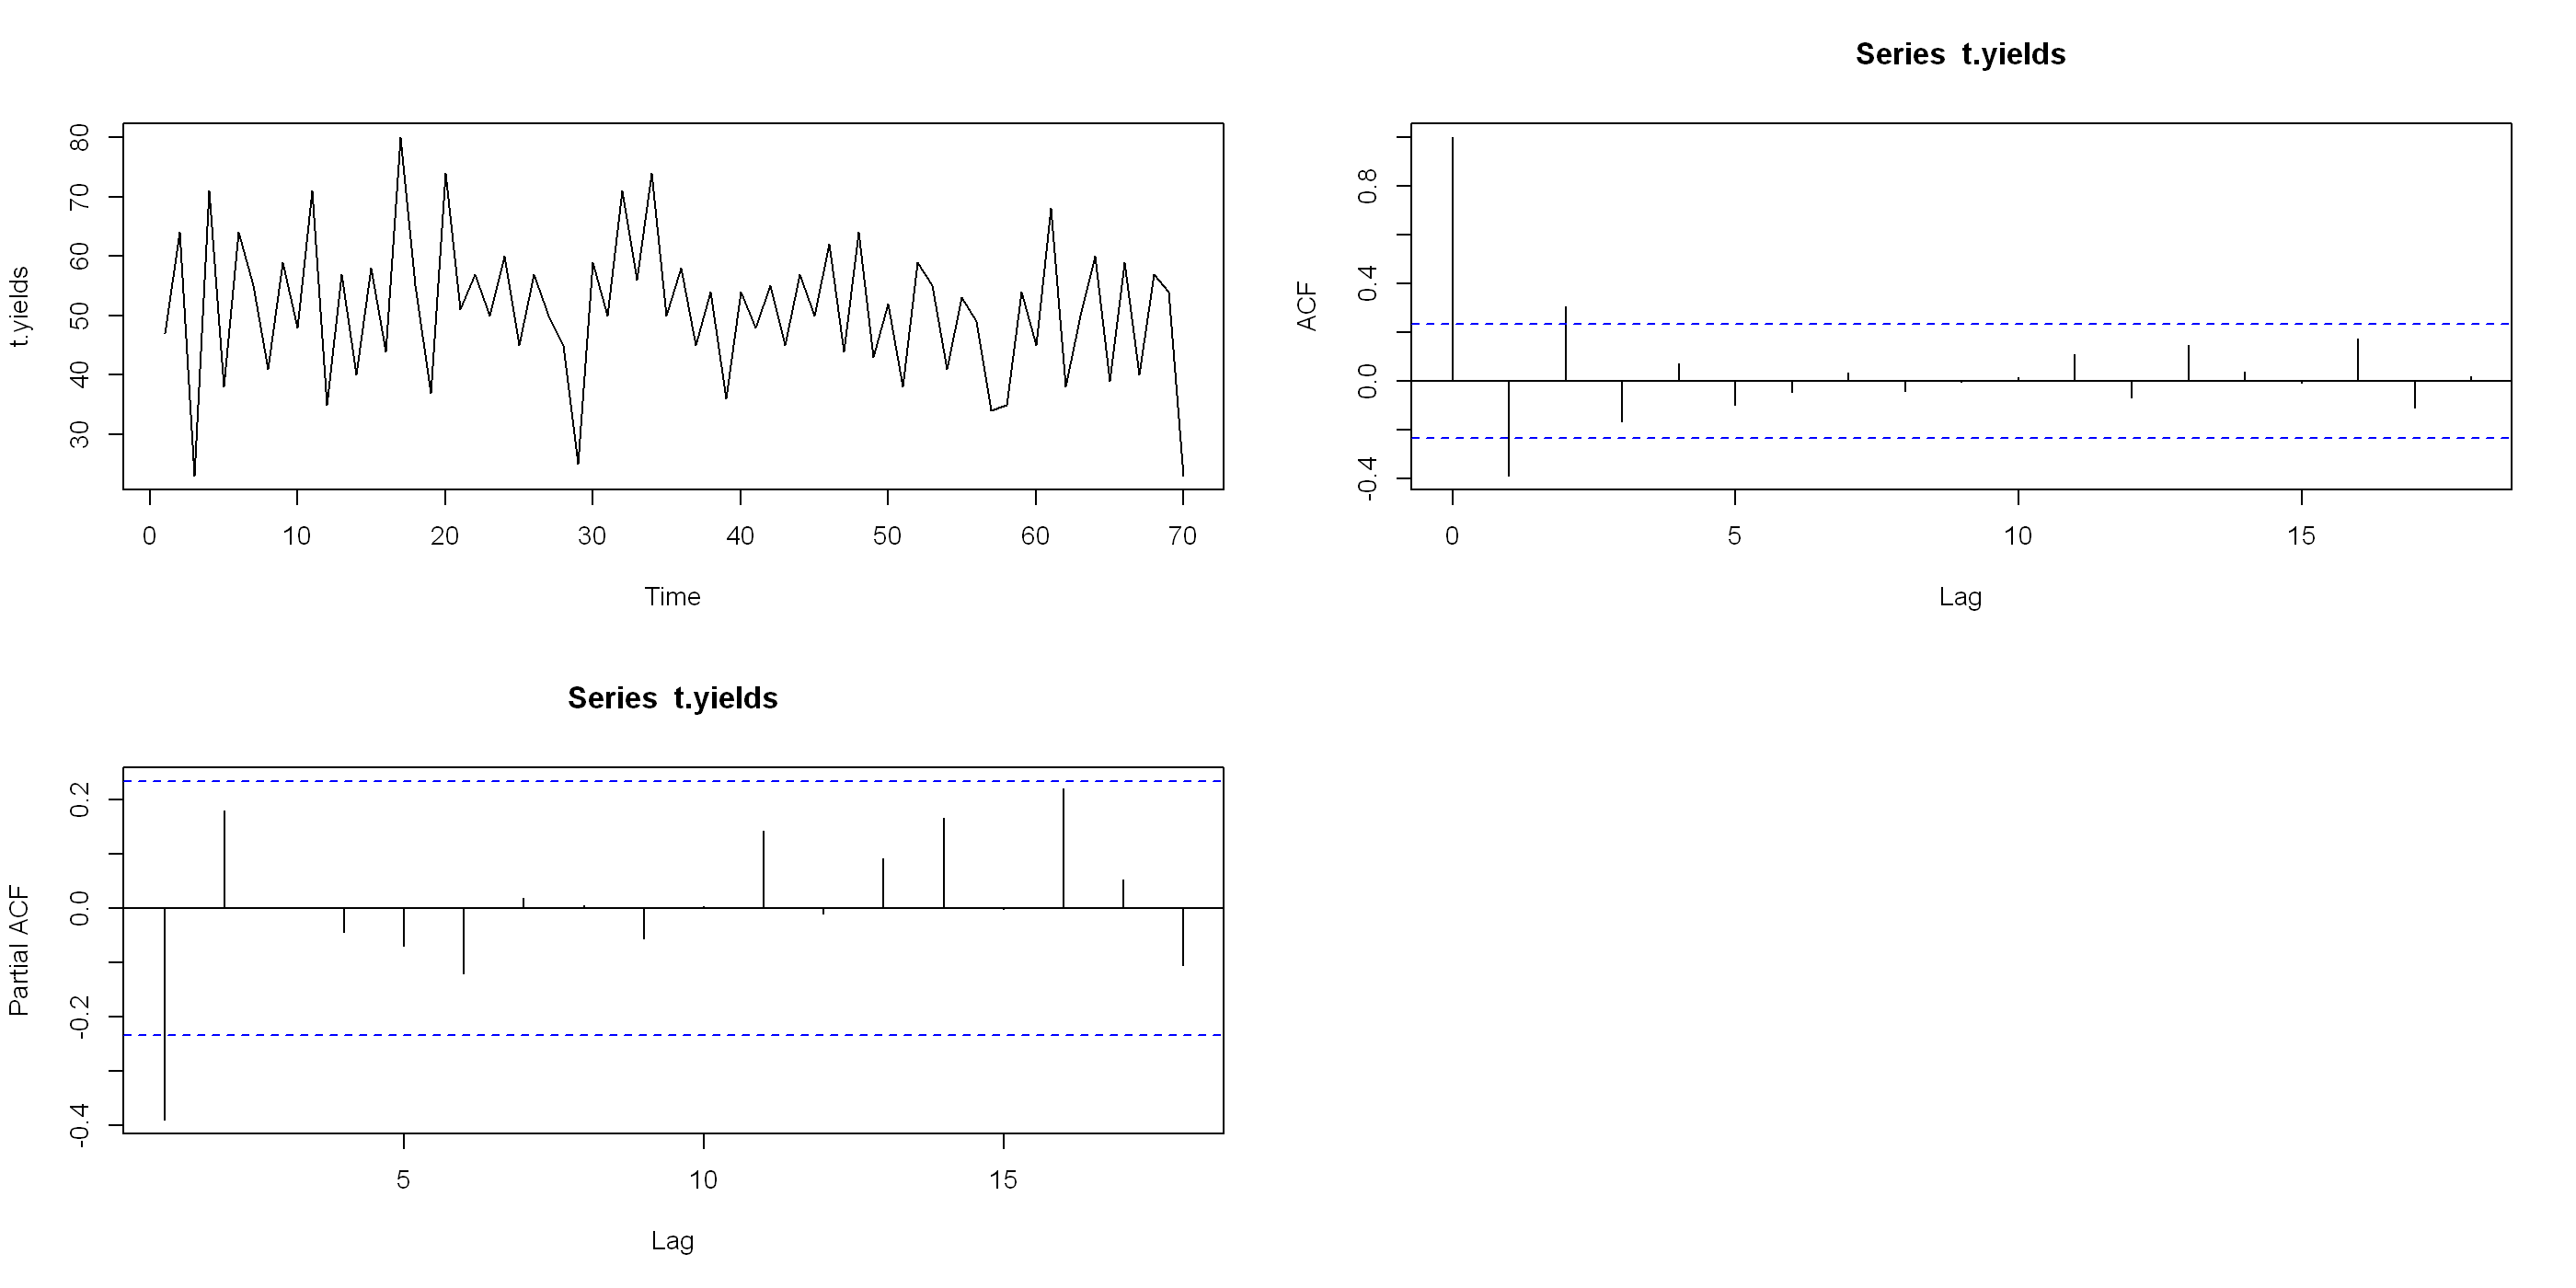

In [4]:
par(mfrow = c(2,2))

plot(t.yields)
t.acf <- acf(t.yields)
pacf(t.yields)

Based on the PACF indeed this could've been generated by an AR(p) process, namely for $p=1$, we still note that the global mean is not zero, hence we argue that the data could've been generated by a shifted AR(1). Hence the we have the following:

$$
X_t-\mu = \alpha_1 (X_{t-1}-\mu)+E_t
$$

where $\mu\approx 50$, $E_t\sim \text{SWN}(0,\sigma^2_E)$

##### b

In [5]:
t.acf[1]


Autocorrelations of series 't.yields', by lag

    1 
-0.39 

The Yule-Walker estimates for $\alpha_i$ is given by

$$
\hat{\rho}(k) = \sum^p_{i=1}\hat{\alpha}_i \hat{\rho}(k-1)
$$

via the argument above, $p=1$ suffices, hence the above simplifies to
$$
\hat{\alpha}_1 = \frac{\hat{\rho}(k)}{\hat{\rho}(k-1)} = \frac{\hat{\rho}(1)}{\hat{\rho}(1-1)} = \frac{-0.390}{1} = -0.390
$$

We note that we need $\sigma^2_E$ and rewrite the established form:

$$
X_t-\mu=\alpha_1(X_{t-1}-\mu)+E_t \Leftrightarrow E_t = X_t-\mu - \alpha_1(X_{t-1}-\mu)
$$



we take the variance
$$Var(E_t) = Var(X_t-\mu-\alpha_1(X_{t-1}-\mu)) = Var(X_t-\mu)+\alpha_1^2Var(X_{t-1}-\mu)-2\alpha_1 Cov(X_t-\mu,X_{t-1}-\mu) 
$$

$$
= \sigma^2_X (1+\alpha_1^2) - 2\alpha_1 \rho(1) \sigma^2_X = \sigma_X^2(1-\alpha_1^2)
$$

In [6]:
n <- length(t.yields)
mu_hat = sum(t.yields)/n
p = 1
print(mu_hat)
sigma_2_hat_X = sum((t.yields-mu_hat)**2)/(n-(p+1))
print(sigma_2_hat_X*(1-(-0.39)**2))


[1] 51.12857
[1] 122.0208


In [7]:
r.yw<-ar(t.yields,method = "yw",order.max = 1)
str(r.yw)
print(r.yw$x.mean)
print(r.yw$var.pred)



List of 15
 $ order       : int 1
 $ ar          : num -0.39
 $ var.pred    : num 122
 $ x.mean      : num 51.1
 $ aic         : Named num [1:2] 9.54 0
  ..- attr(*, "names")= chr [1:2] "0" "1"
 $ n.used      : int 70
 $ n.obs       : int 70
 $ order.max   : num 1
 $ partialacf  : num [1, 1, 1] -0.39
 $ resid       : Time-Series [1:70] from 1 to 70: NA 11.26 -23.11 8.9 -5.38 ...
 $ method      : chr "Yule-Walker"
 $ series      : chr "t.yields"
 $ frequency   : num 1
 $ call        : language ar(x = t.yields, order.max = 1, method = "yw")
 $ asy.var.coef: num [1, 1] 0.0125
 - attr(*, "class")= chr "ar"
[1] 51.12857
[1] 122.0345


##### c


In [8]:
r.burg <- ar(t.yields,method = "burg",order.max = 1)
str(r.burg)
print(r.burg$var.pred)
print(r.burg$x.mean)

List of 15
 $ order       : int 1
 $ ar          : num -0.407
 $ var.pred    : num 117
 $ x.mean      : num 51.1
 $ aic         : Named num [1:2] 10.7 0
  ..- attr(*, "names")= chr [1:2] "0" "1"
 $ n.used      : int 70
 $ n.obs       : int 70
 $ order.max   : num 1
 $ partialacf  : num [1, 1, 1] -0.407
 $ resid       : Time-Series [1:70] from 1 to 70: NA 11.19 -22.89 8.43 -5.05 ...
 $ method      : chr "Burg"
 $ series      : chr "t.yields"
 $ frequency   : num 1
 $ call        : language ar(x = t.yields, order.max = 1, method = "burg")
 $ asy.var.coef: num [1, 1] 0.0119
 - attr(*, "class")= chr "ar"
[1] 116.6776
[1] 51.12857


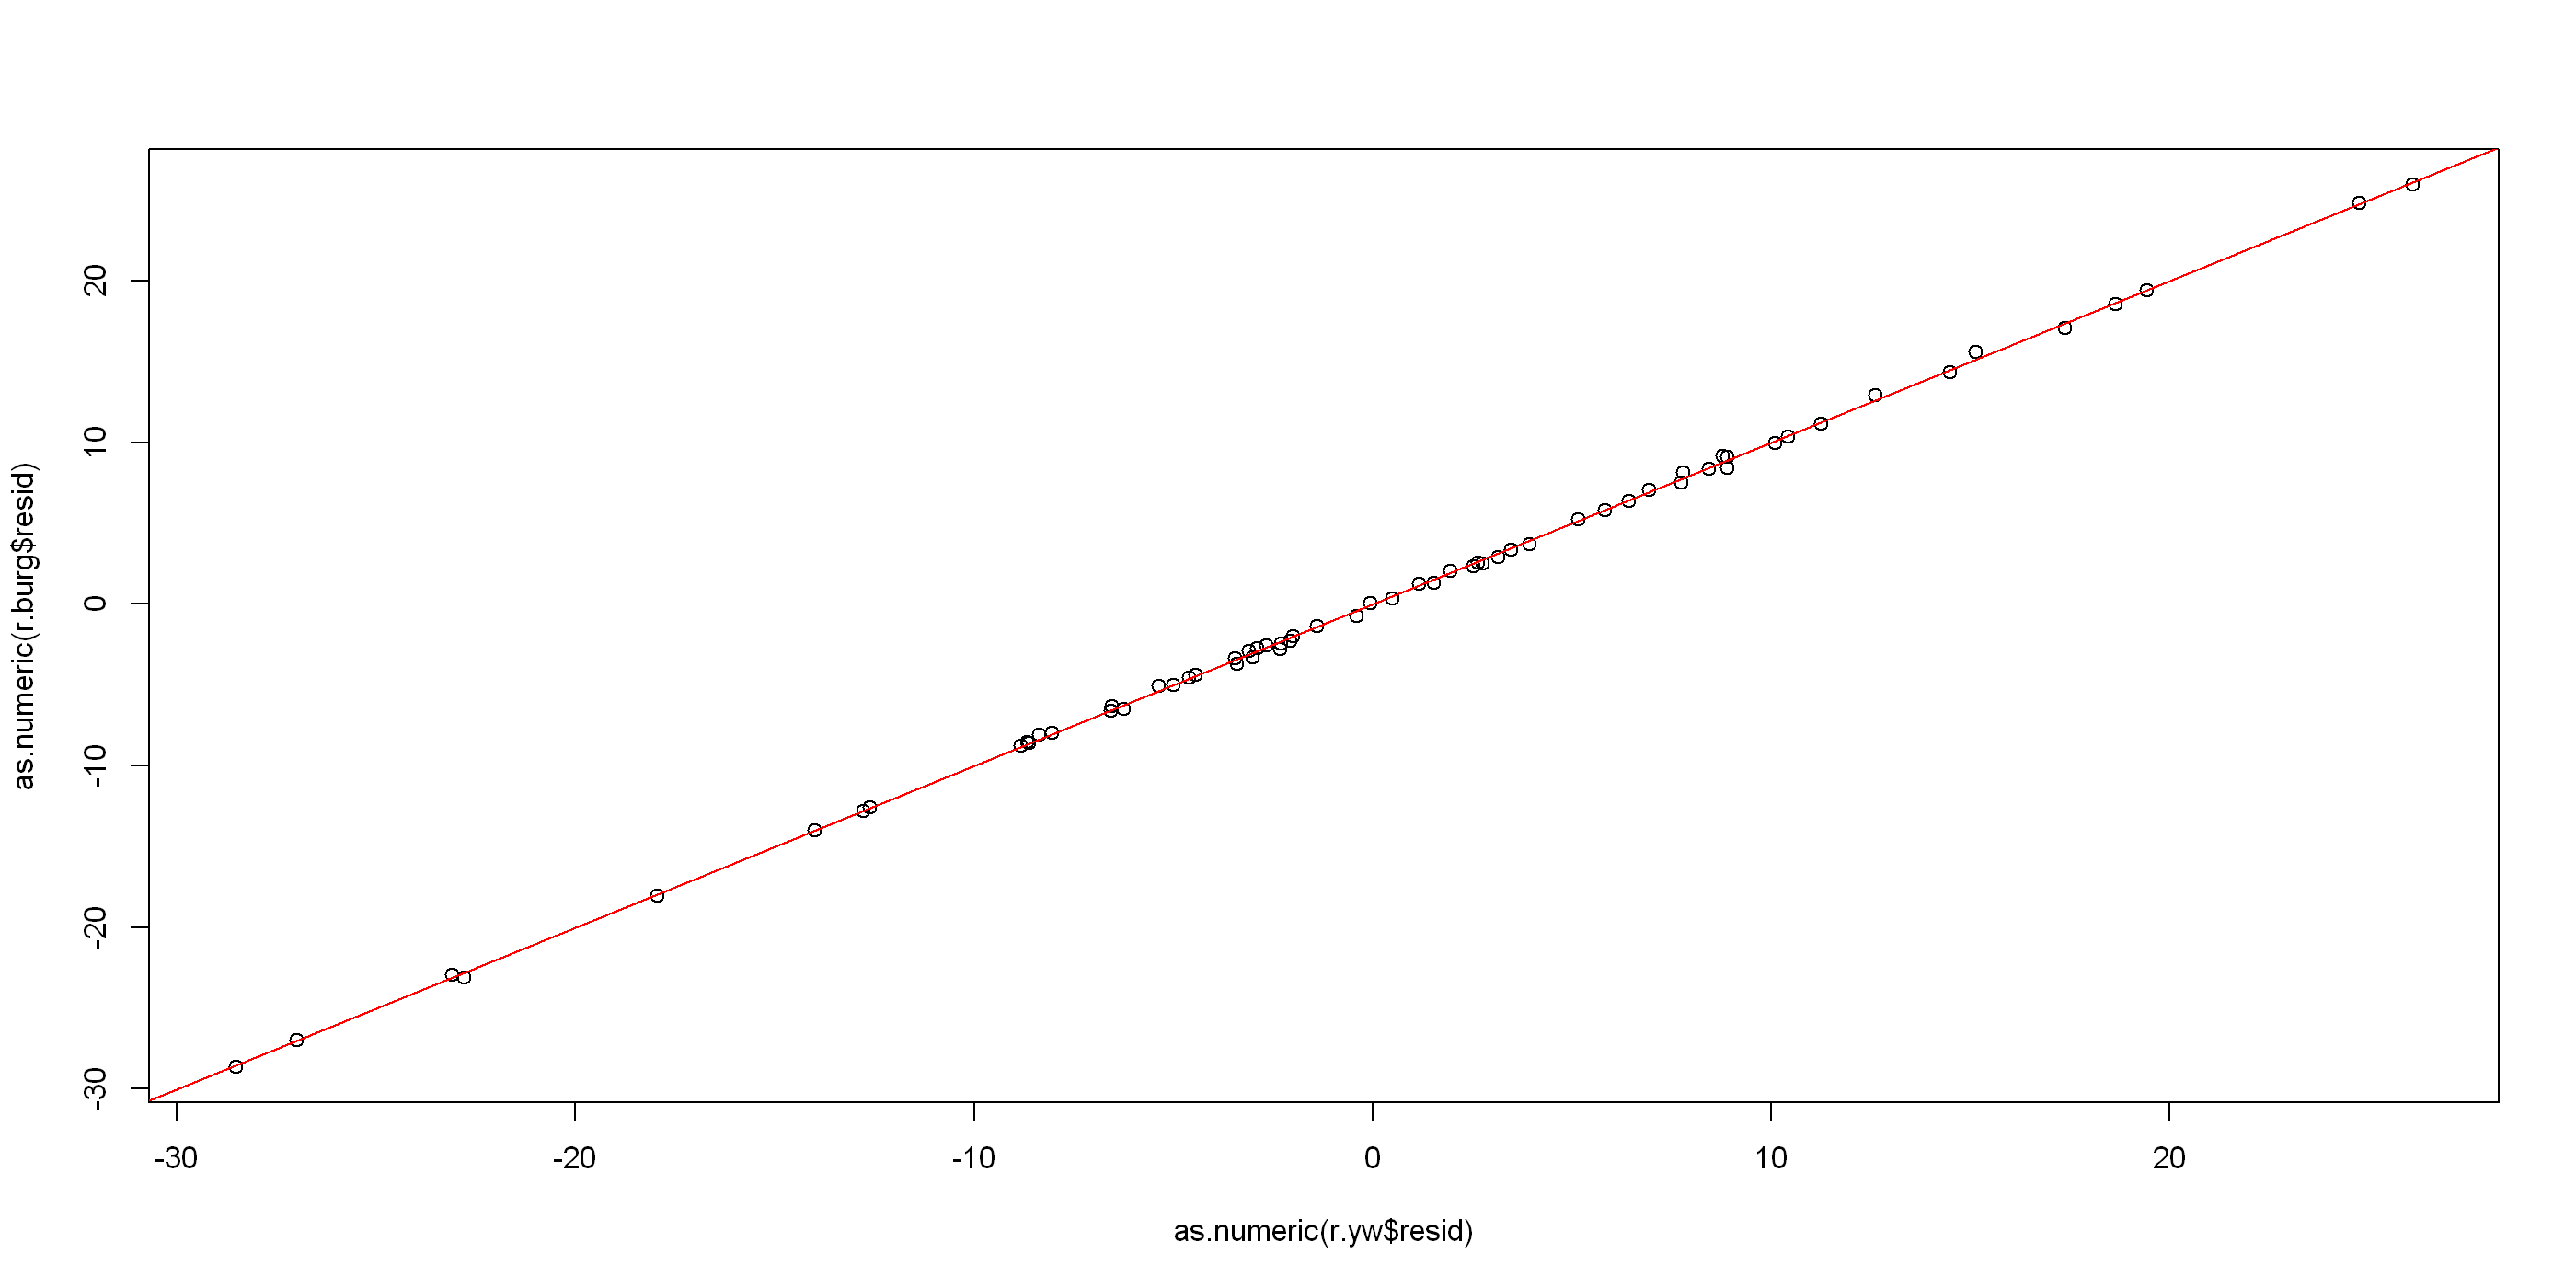

In [9]:
plot(x=as.numeric(r.yw$resid), y=as.numeric(r.burg$resid))
abline(coef = c(0,1),col="red")


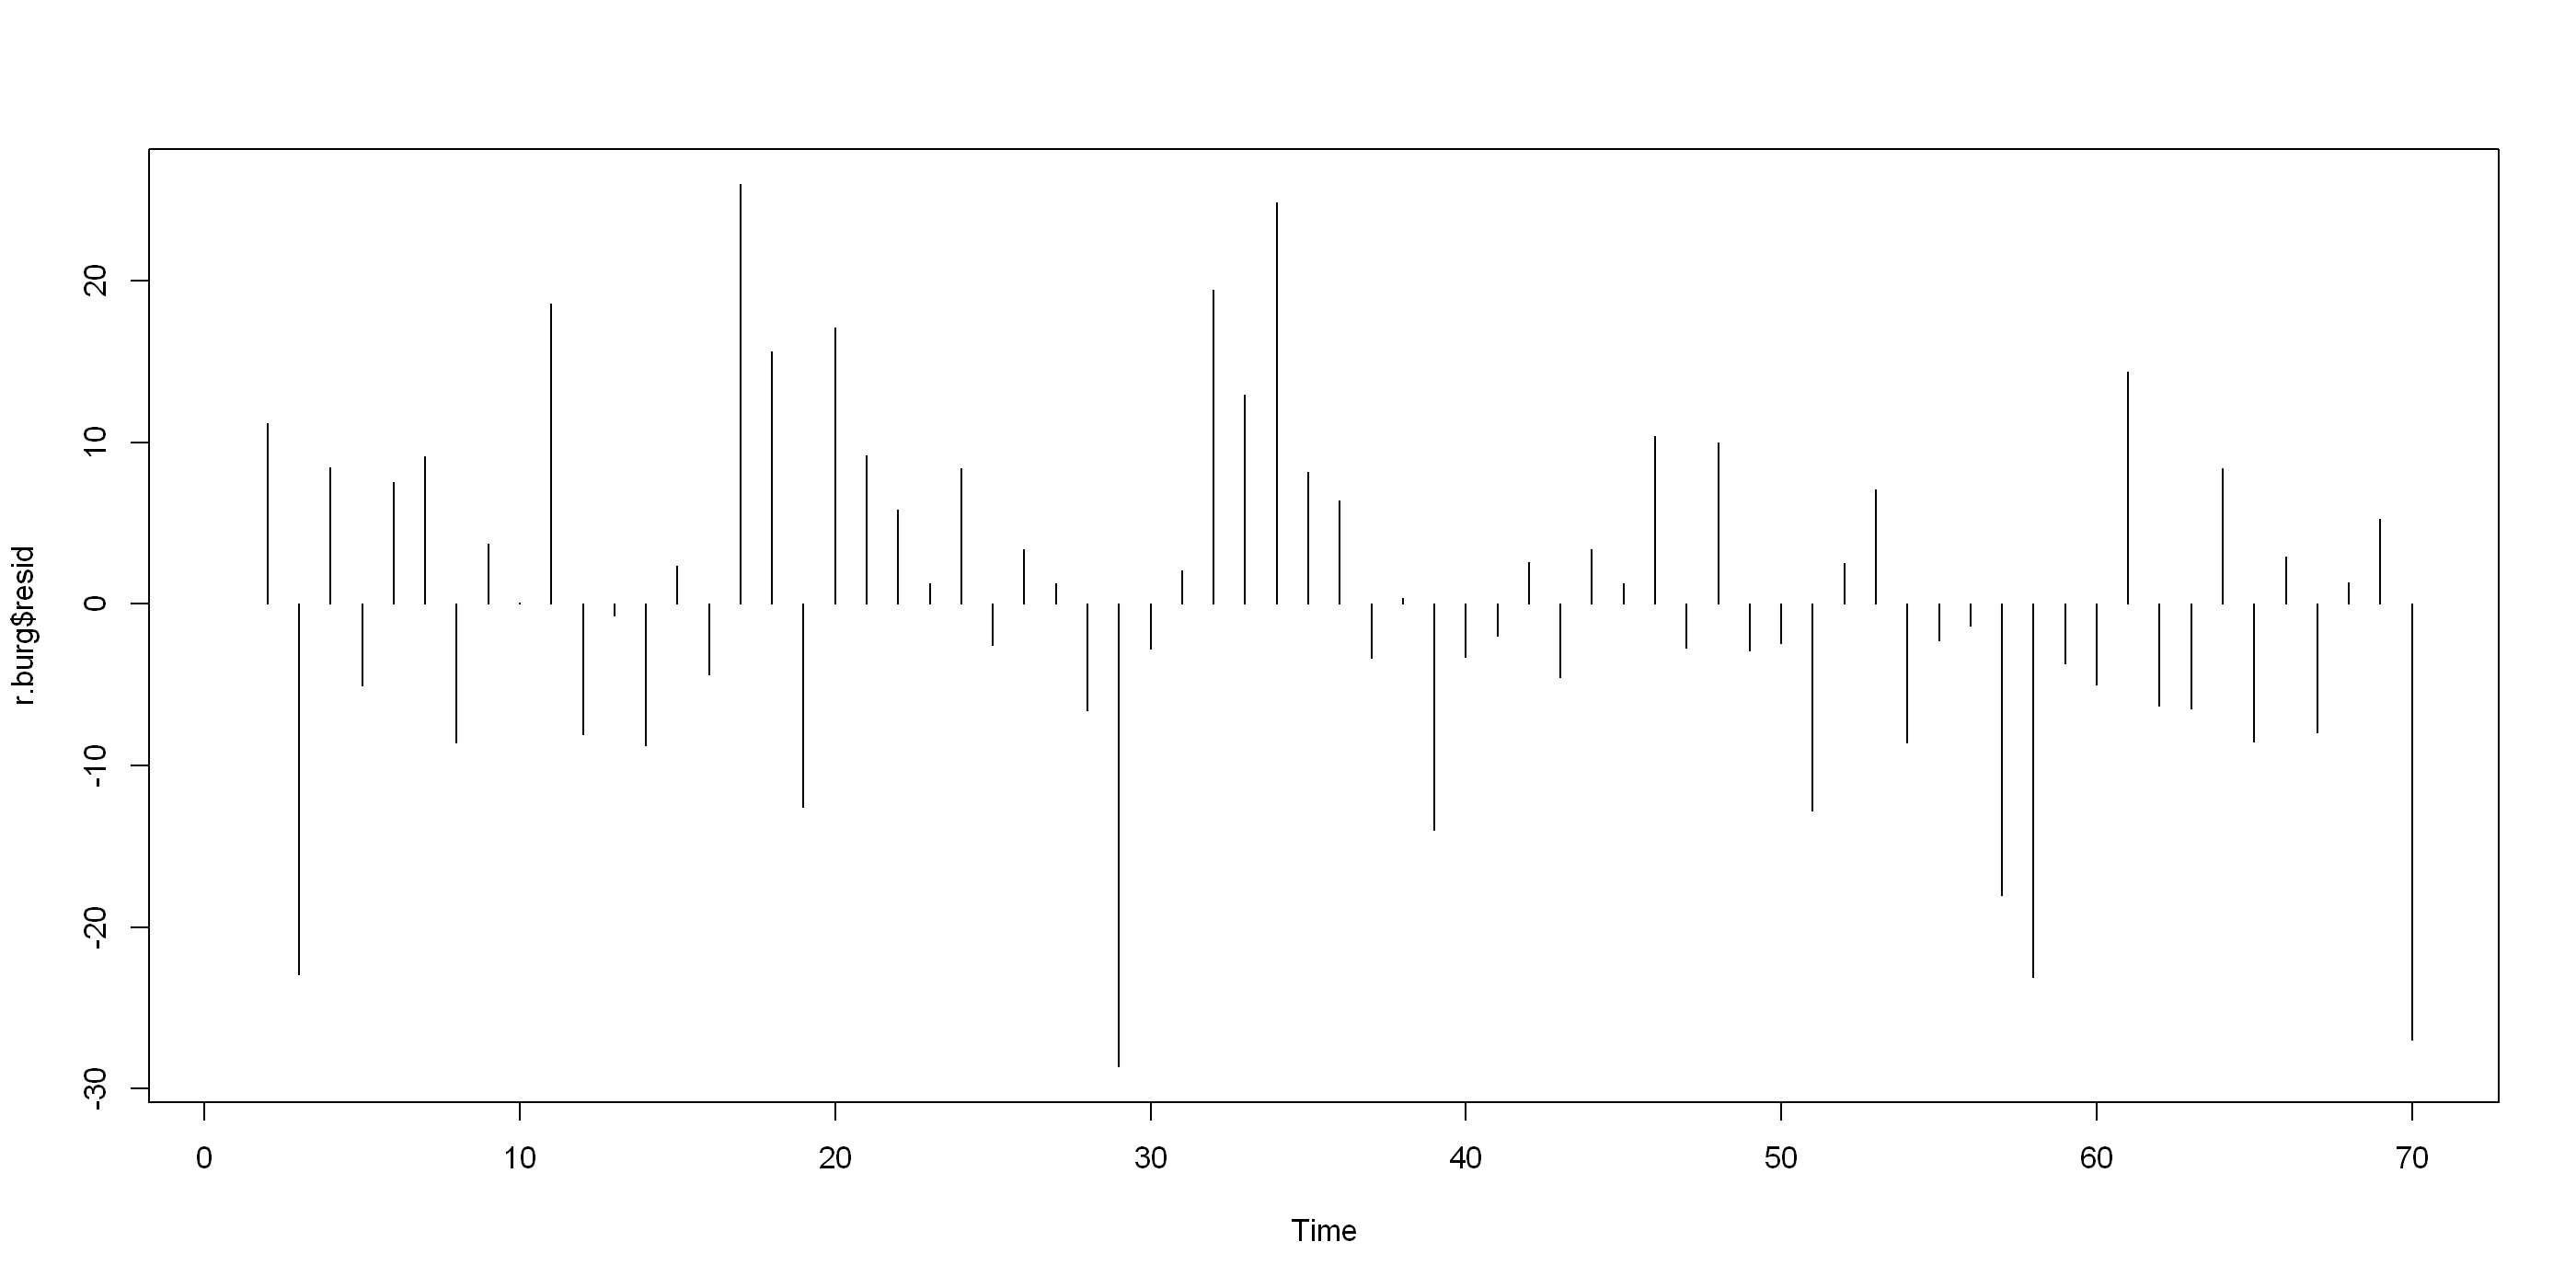

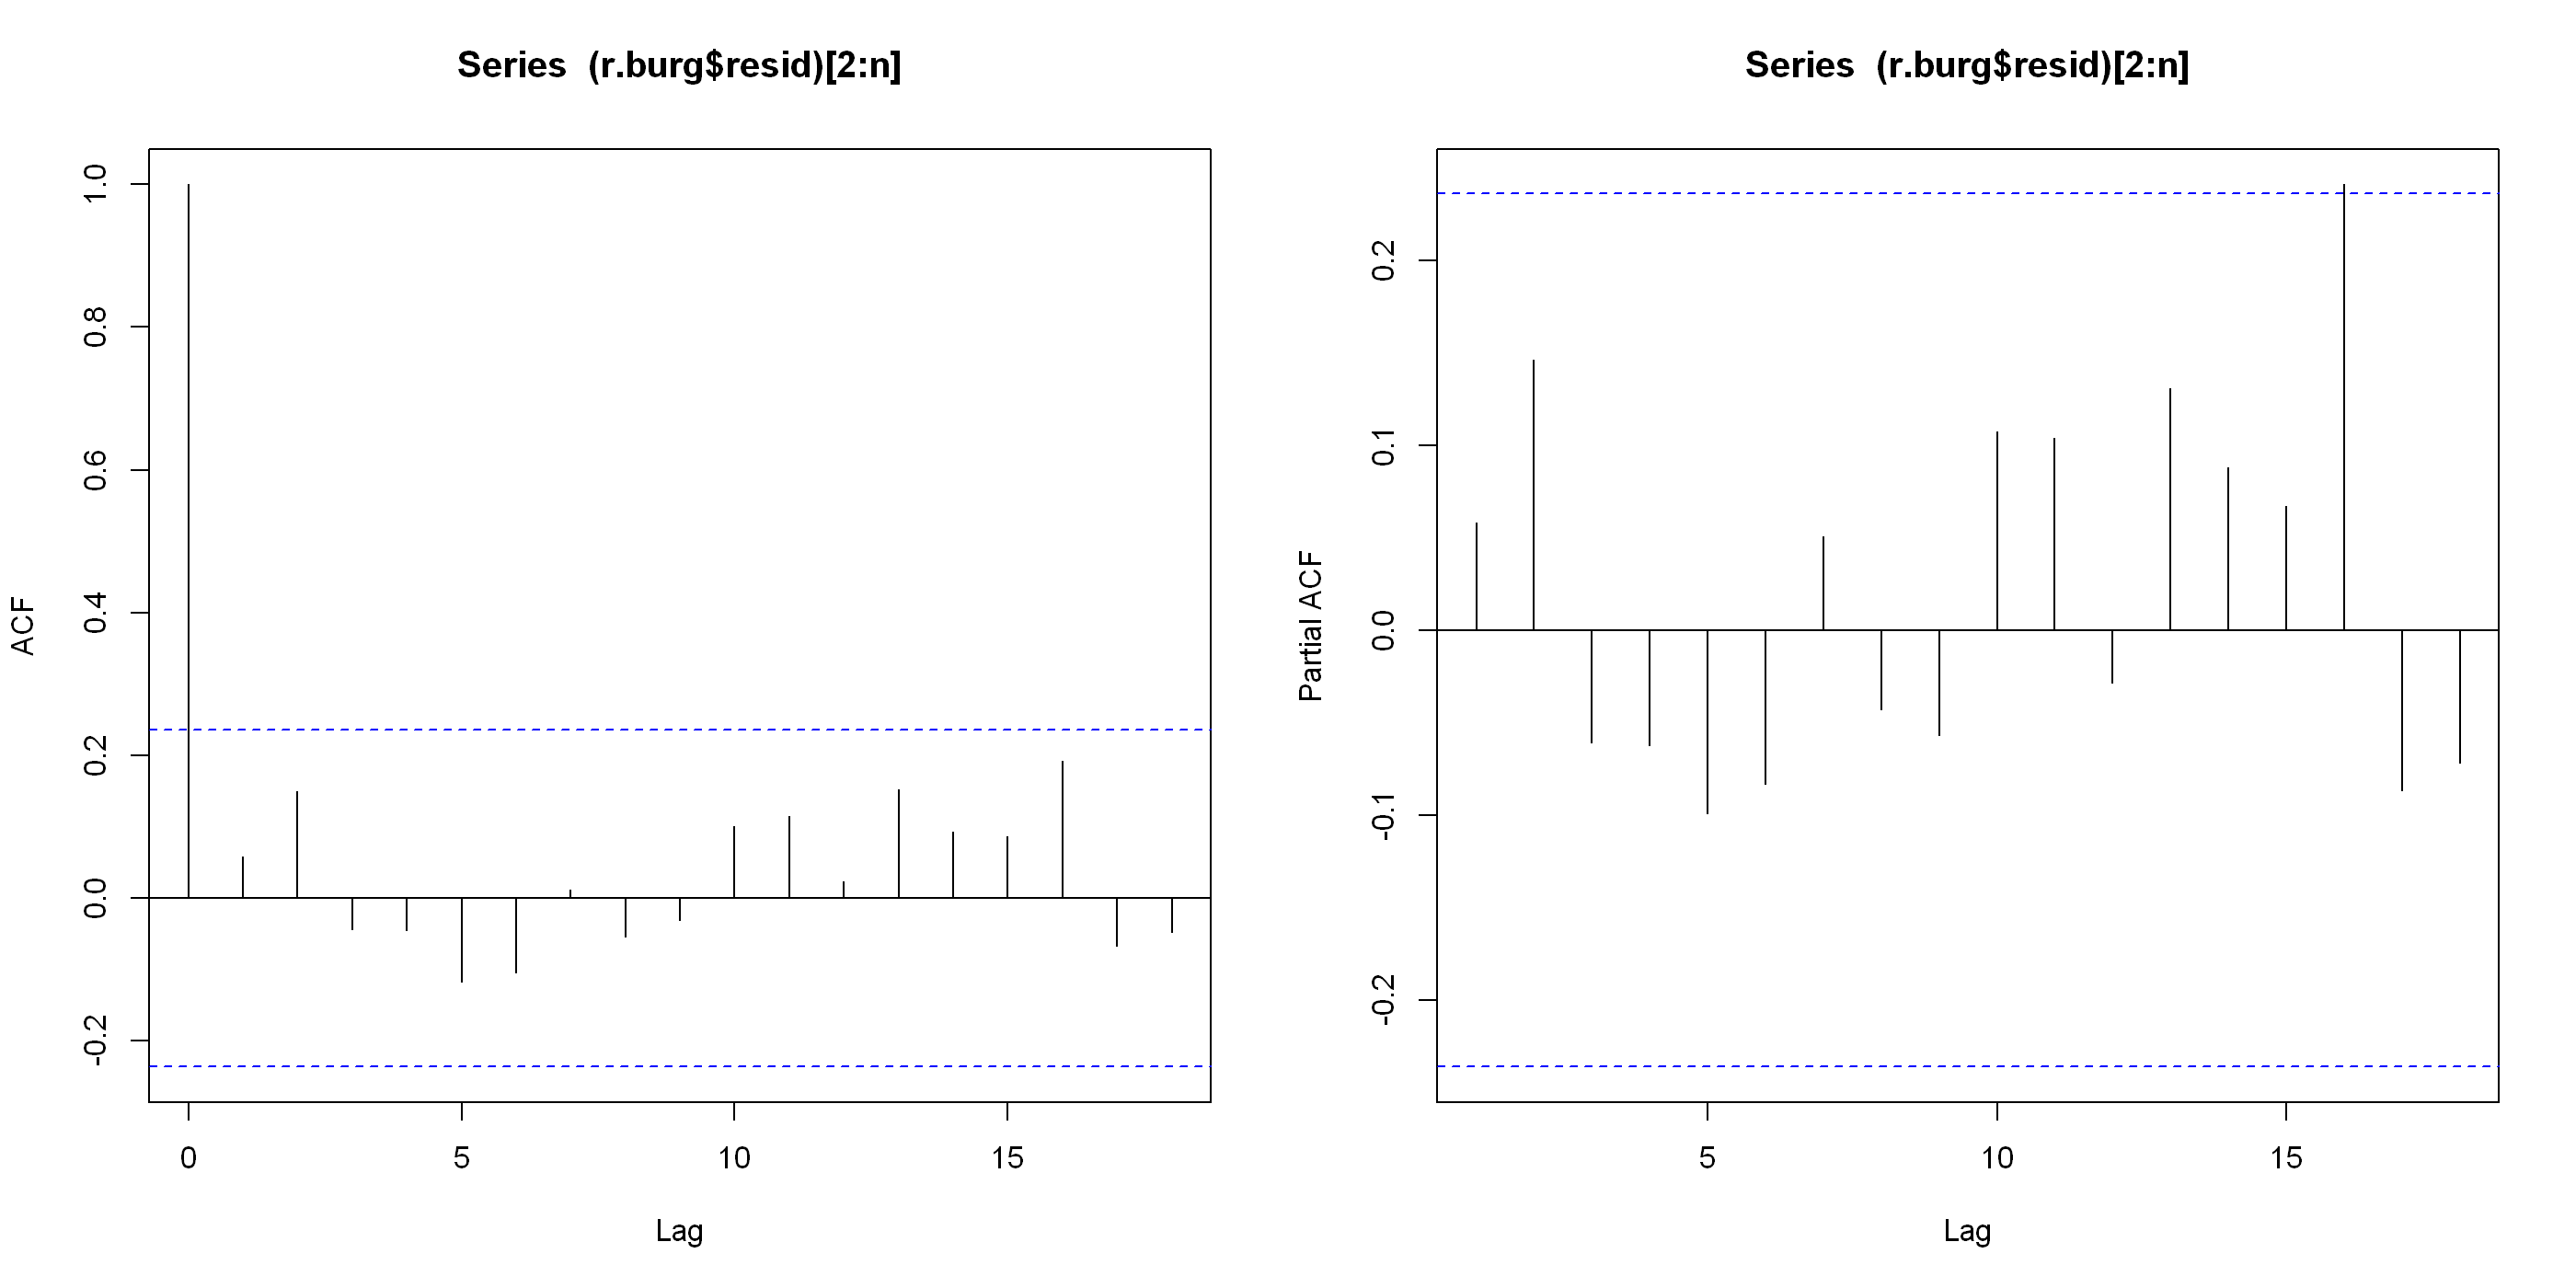

In [10]:
plot(r.burg$resid,type="h")
par(mfrow = c(1,2))
acf((r.burg$resid)[2:n])
pacf((r.burg$resid)[2:n])

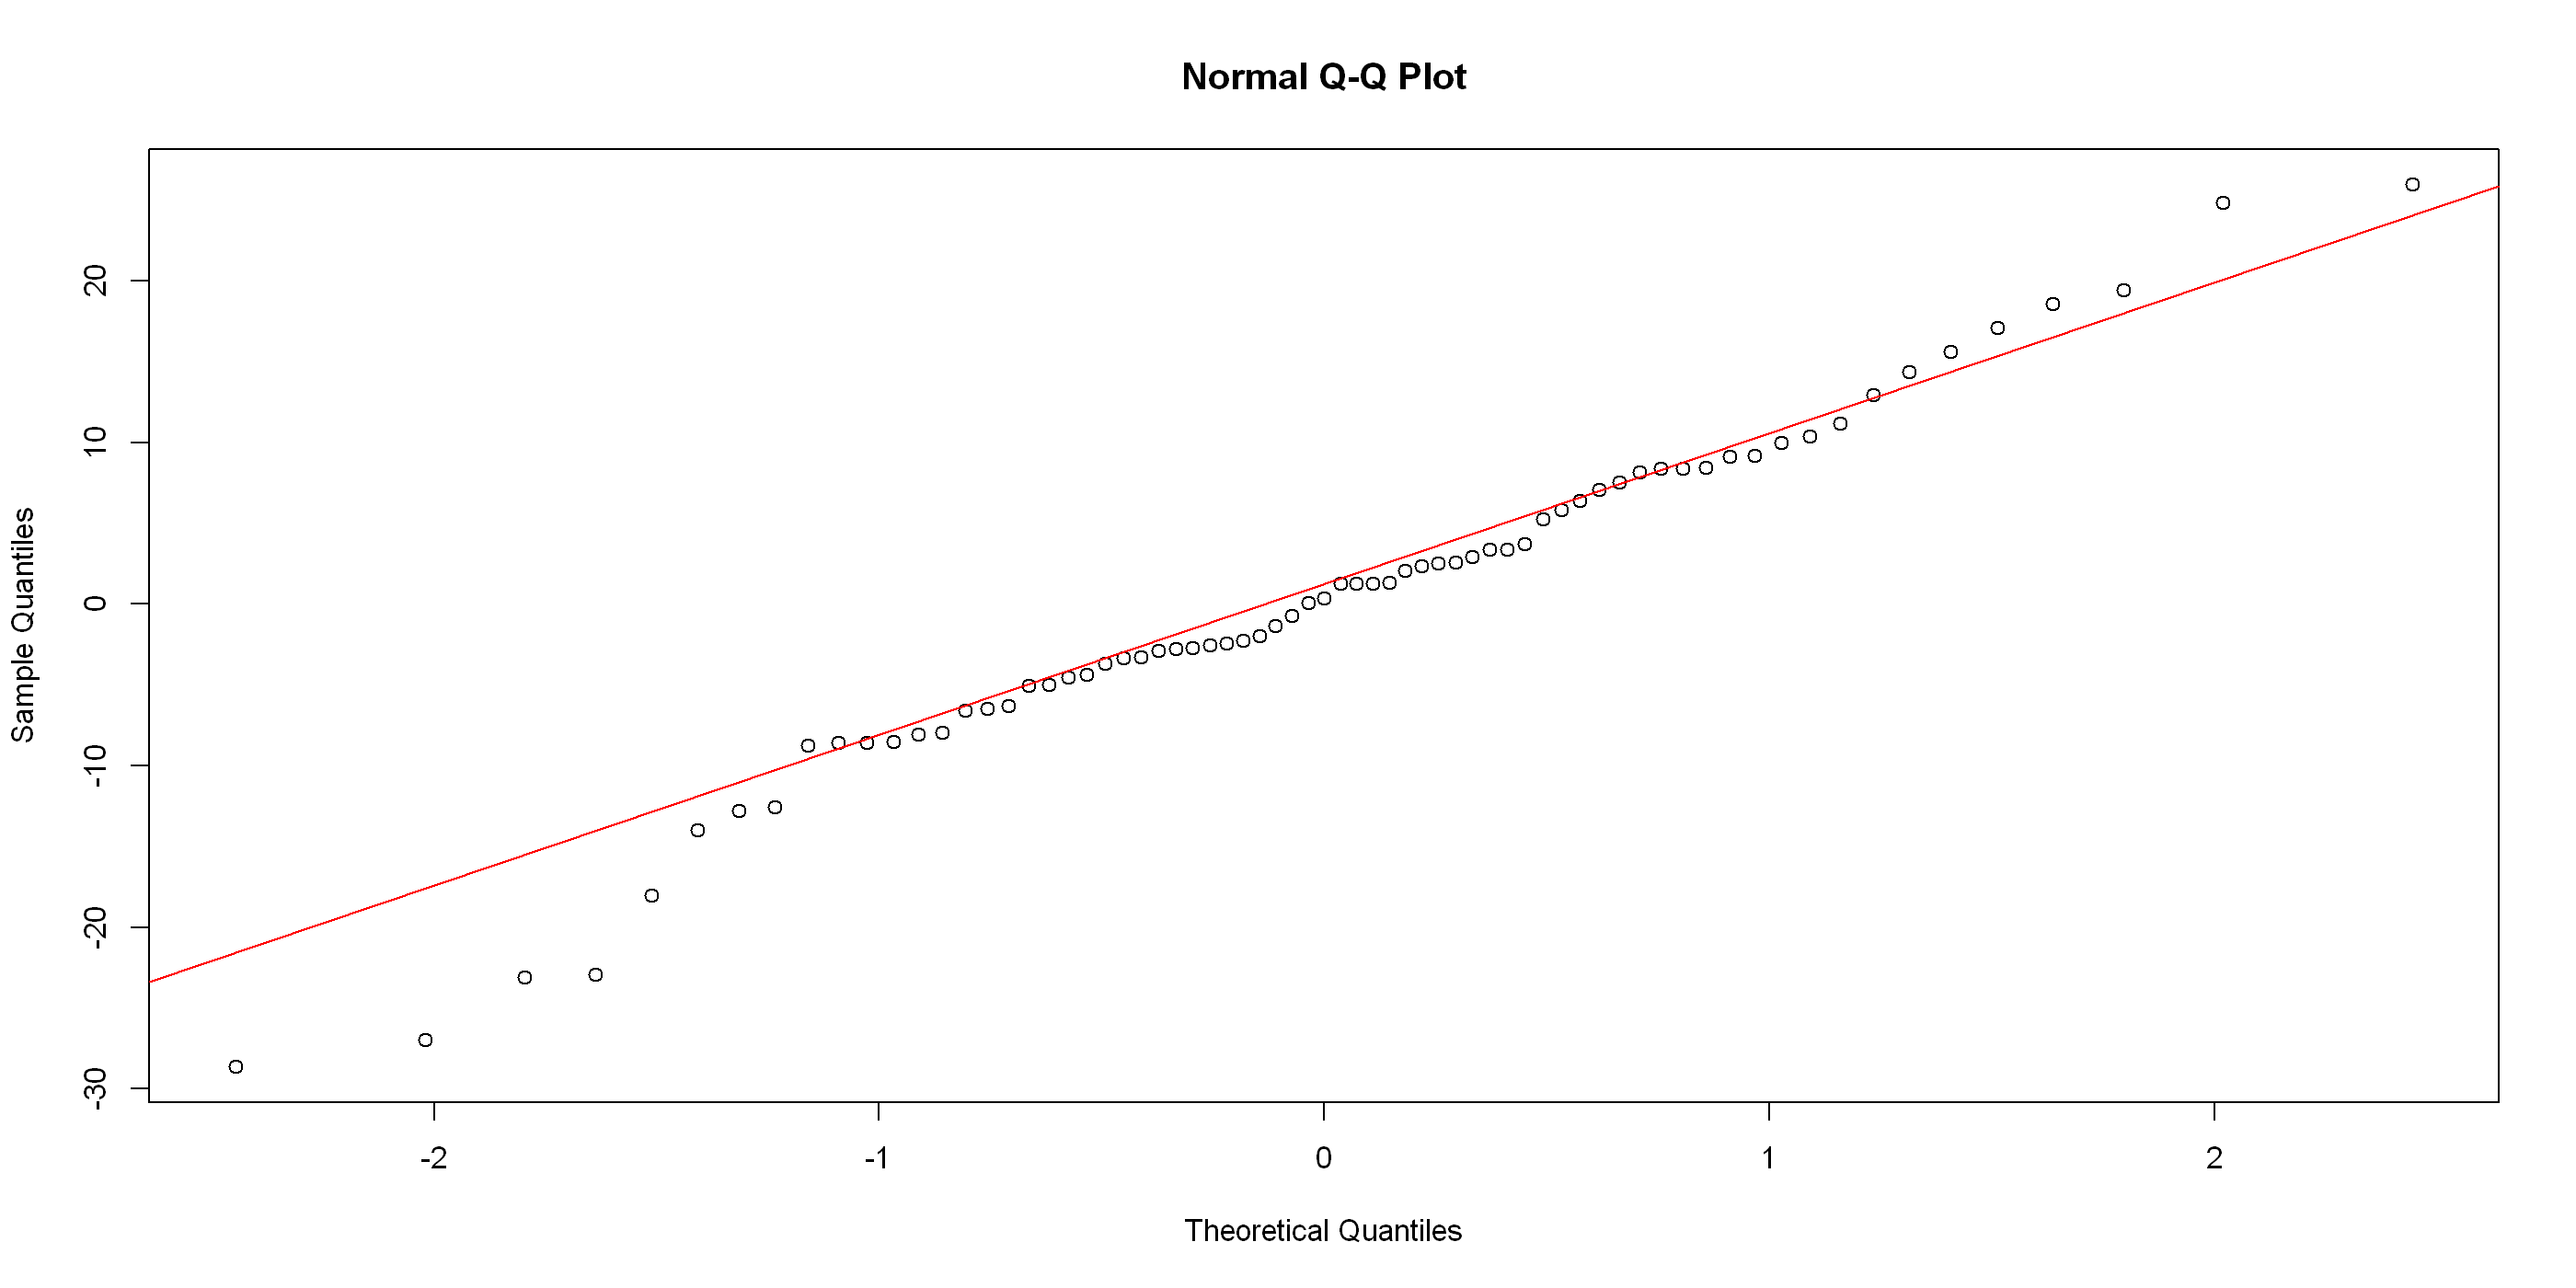

In [11]:
qqnorm(r.burg$resid)
qqline(r.burg$resid,col="red")

##### d

In [12]:
r.mle<-arima(t.yields,order=c(1,0,0),method = "ML",include.mean = T)
str(r.mle)
sigma_mu = sqrt(r.mle$var.coef[2,2])
z95 = qnorm(1-0.05/2)
CI_MLE = c(r.mle$coef[2]-z95*sigma_mu,r.mle$coef[2]+z95*sigma_mu)

List of 14
 $ coef     : Named num [1:2] -0.419 51.266
  ..- attr(*, "names")= chr [1:2] "ar1" "intercept"
 $ sigma2   : num 117
 $ var.coef : num [1:2, 1:2] 0.01274 -0.00296 -0.00296 0.8348
  ..- attr(*, "dimnames")=List of 2
  .. ..$ : chr [1:2] "ar1" "intercept"
  .. ..$ : chr [1:2] "ar1" "intercept"
 $ mask     : logi [1:2] TRUE TRUE
 $ loglik   : num -266
 $ aic      : num 538
 $ arma     : int [1:7] 1 0 0 0 1 0 0
 $ residuals: Time-Series [1:70] from 1 to 70: -3.87 10.95 -22.93 7.89 -4.99 ...
 $ call     : language arima(x = t.yields, order = c(1, 0, 0), include.mean = T, method = "ML")
 $ series   : chr "t.yields"
 $ code     : int 0
 $ n.cond   : num 0
 $ nobs     : int 70
 $ model    :List of 10
  ..$ phi  : num -0.419
  ..$ theta: num(0) 
  ..$ Delta: num(0) 
  ..$ Z    : num 1
  ..$ a    : num -28.3
  ..$ P    : num [1, 1] 0
  ..$ T    : num [1, 1] -0.419
  ..$ V    : num [1, 1] 1
  ..$ h    : num 0
  ..$ Pn   : num [1, 1] 1
 - attr(*, "class")= chr "Arima"


##### e

From lecture we have 
$$
Var(\hat{\mu}) = \frac{\gamma(0)}{n^2}\left(n+2\sum^{n-1}_{k=1}(n-k)\rho(k)\right)
$$

and since the lag $k=1$ this reduces to

$$
Var(\hat{\mu}) = \frac{\gamma(0)}{n^2}\left(n+2\sum^{n-1}_{k=1}(n-k) \hat{\alpha}_1^k\right)
$$


In [13]:
s = 0
for(k in 1:(n-1))
{
   s <- s+(n-k)*r.burg$ar**k
}

sigma_mu_burg = sqrt(((r.burg$var.pred)/((1-r.burg$ar**2)*n**2))*(n+2*s))

CI_BURG = c(r.burg$x.mean-z95*(sigma_mu_burg),r.burg$x.mean+z95*(sigma_mu_burg))
print(CI_MLE)
print(CI_BURG)

intercept intercept 
 49.47526  53.05679 
[1] 49.31722 52.93992


### 4.2


![ex4_2.png](ex4_2.png)

##### (I)

In (a), there should be a strong autocorrelation and partial correlation at lag = 1,2, and the signs of the coefficients correspond to the sign of the partial autocorrelations. The ACF should show an exponential decay, whilst the PACF should show little signal after lag=2.

In (b), there should be a strong autocorrelation and partial correlation at lag = 1,2,3, and the signs of the coefficients correspond to the sign of the partial autocorrelations. The PACF should show an exponential decay, whilst the ACF should show little signal after lag=3.

In (c), there should be a strong autocorrelation and partial correlation at lag = 1 and a slight one at lag =2, the weight of the MA is essentially slightly stronger hence the series should show more sign of the exponential decay in the PACF, whilst showing a blend in the ACF.


##### (II)

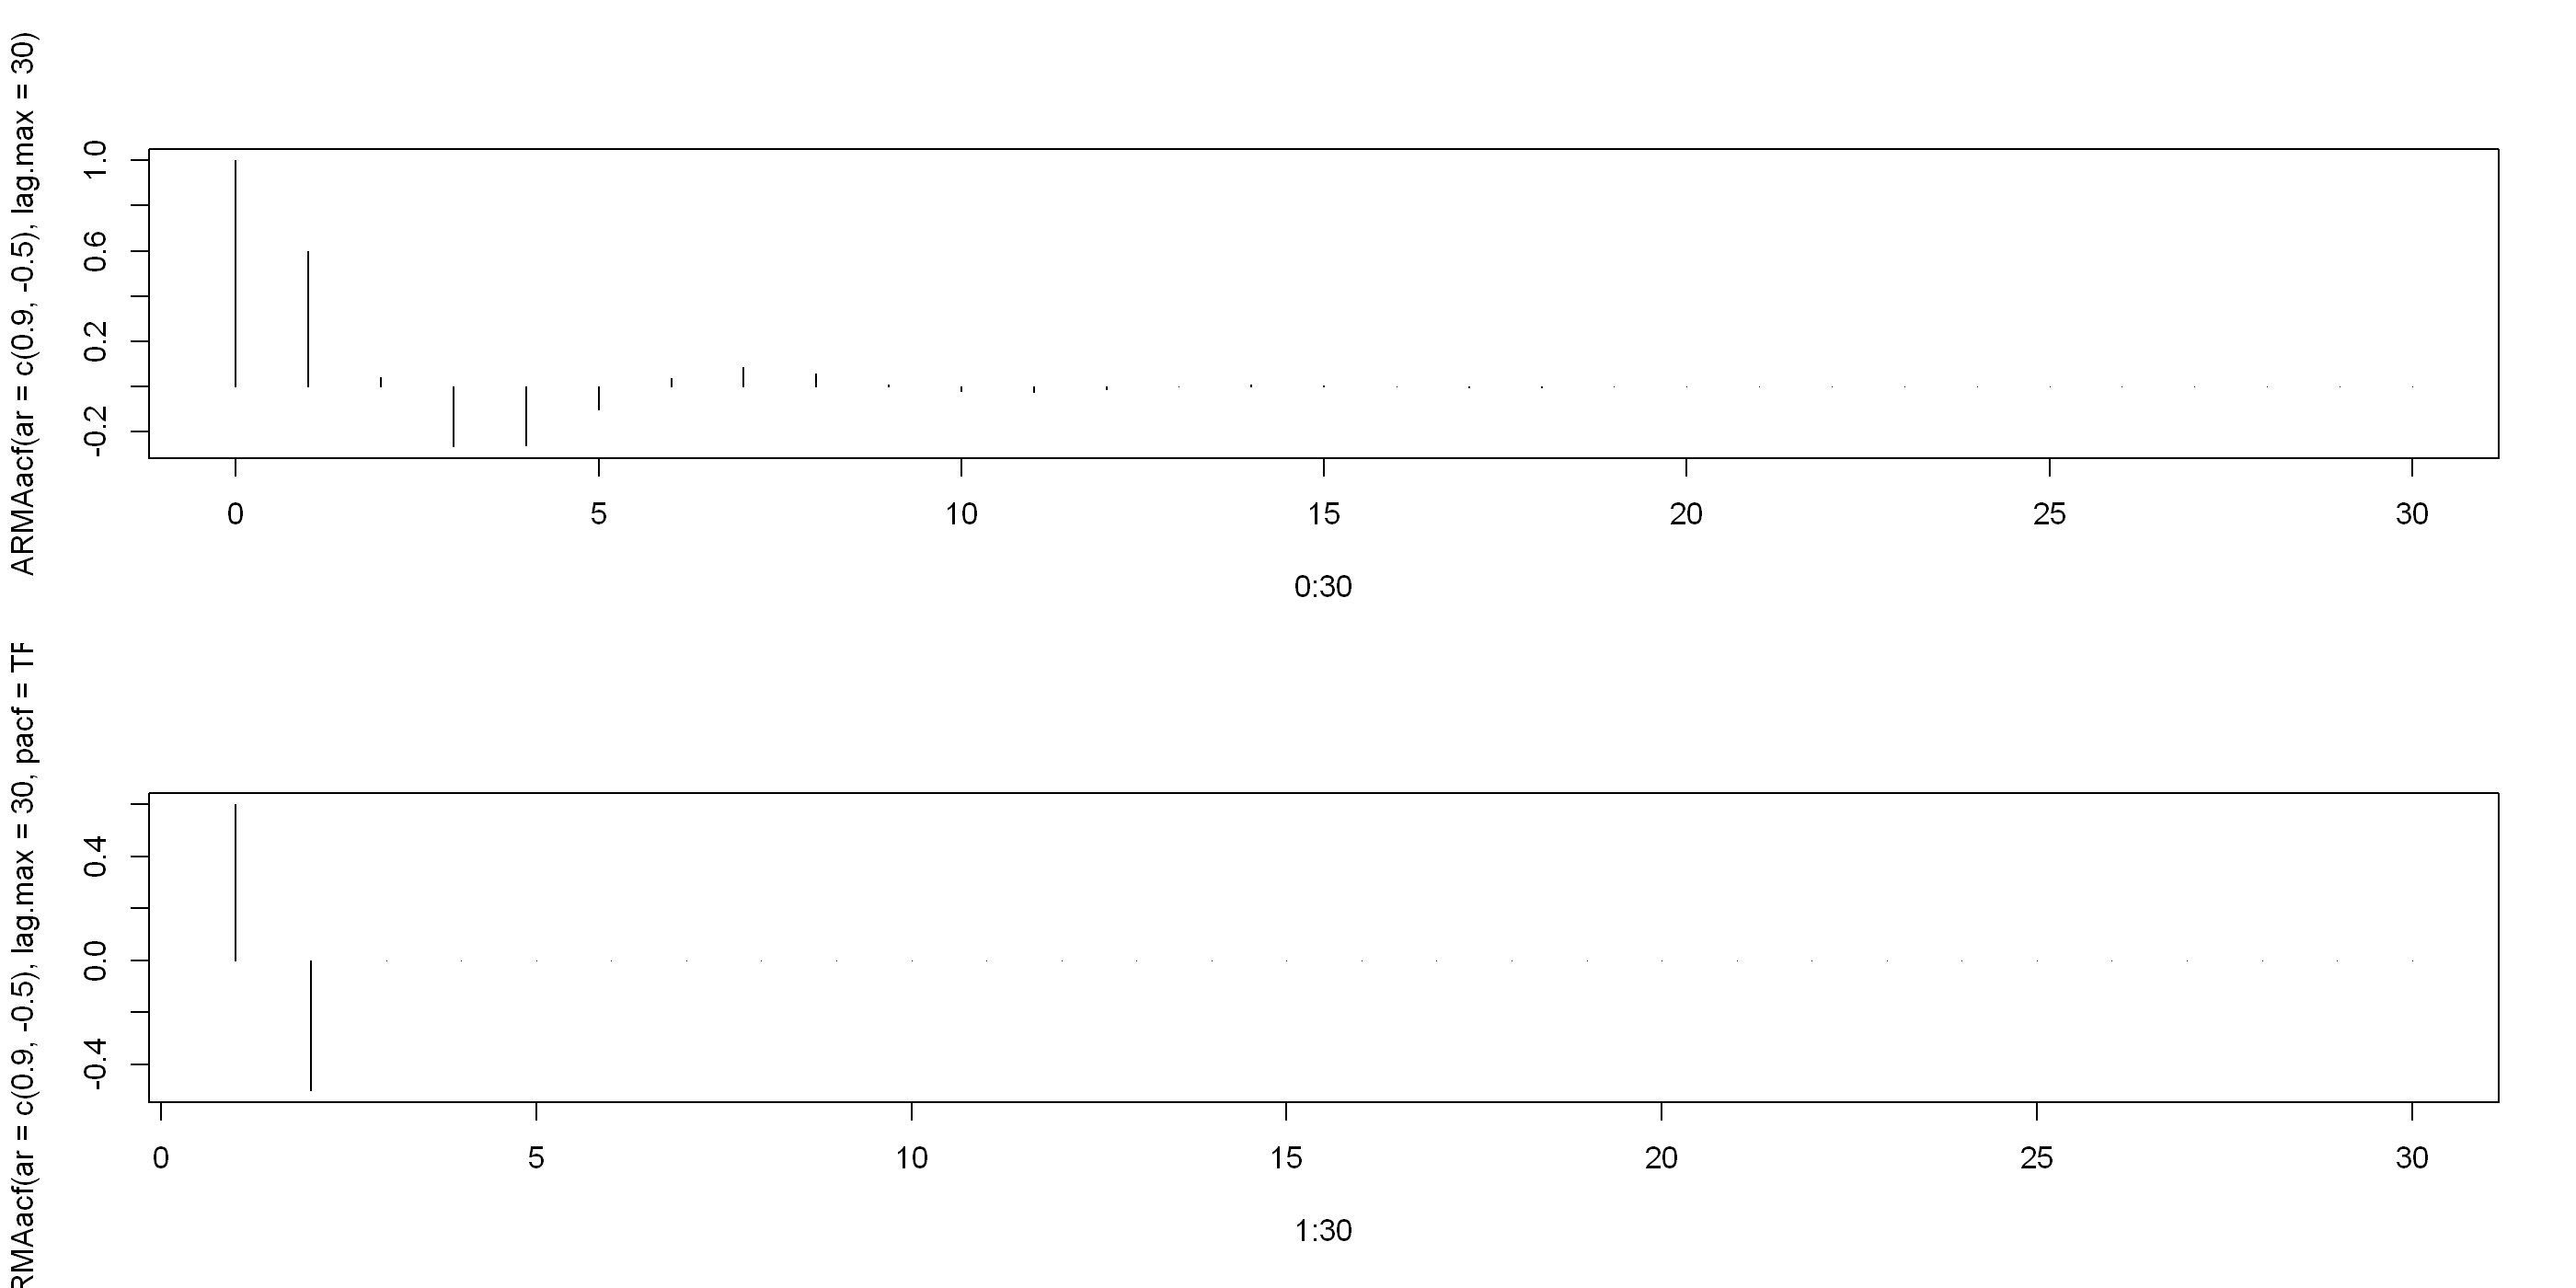

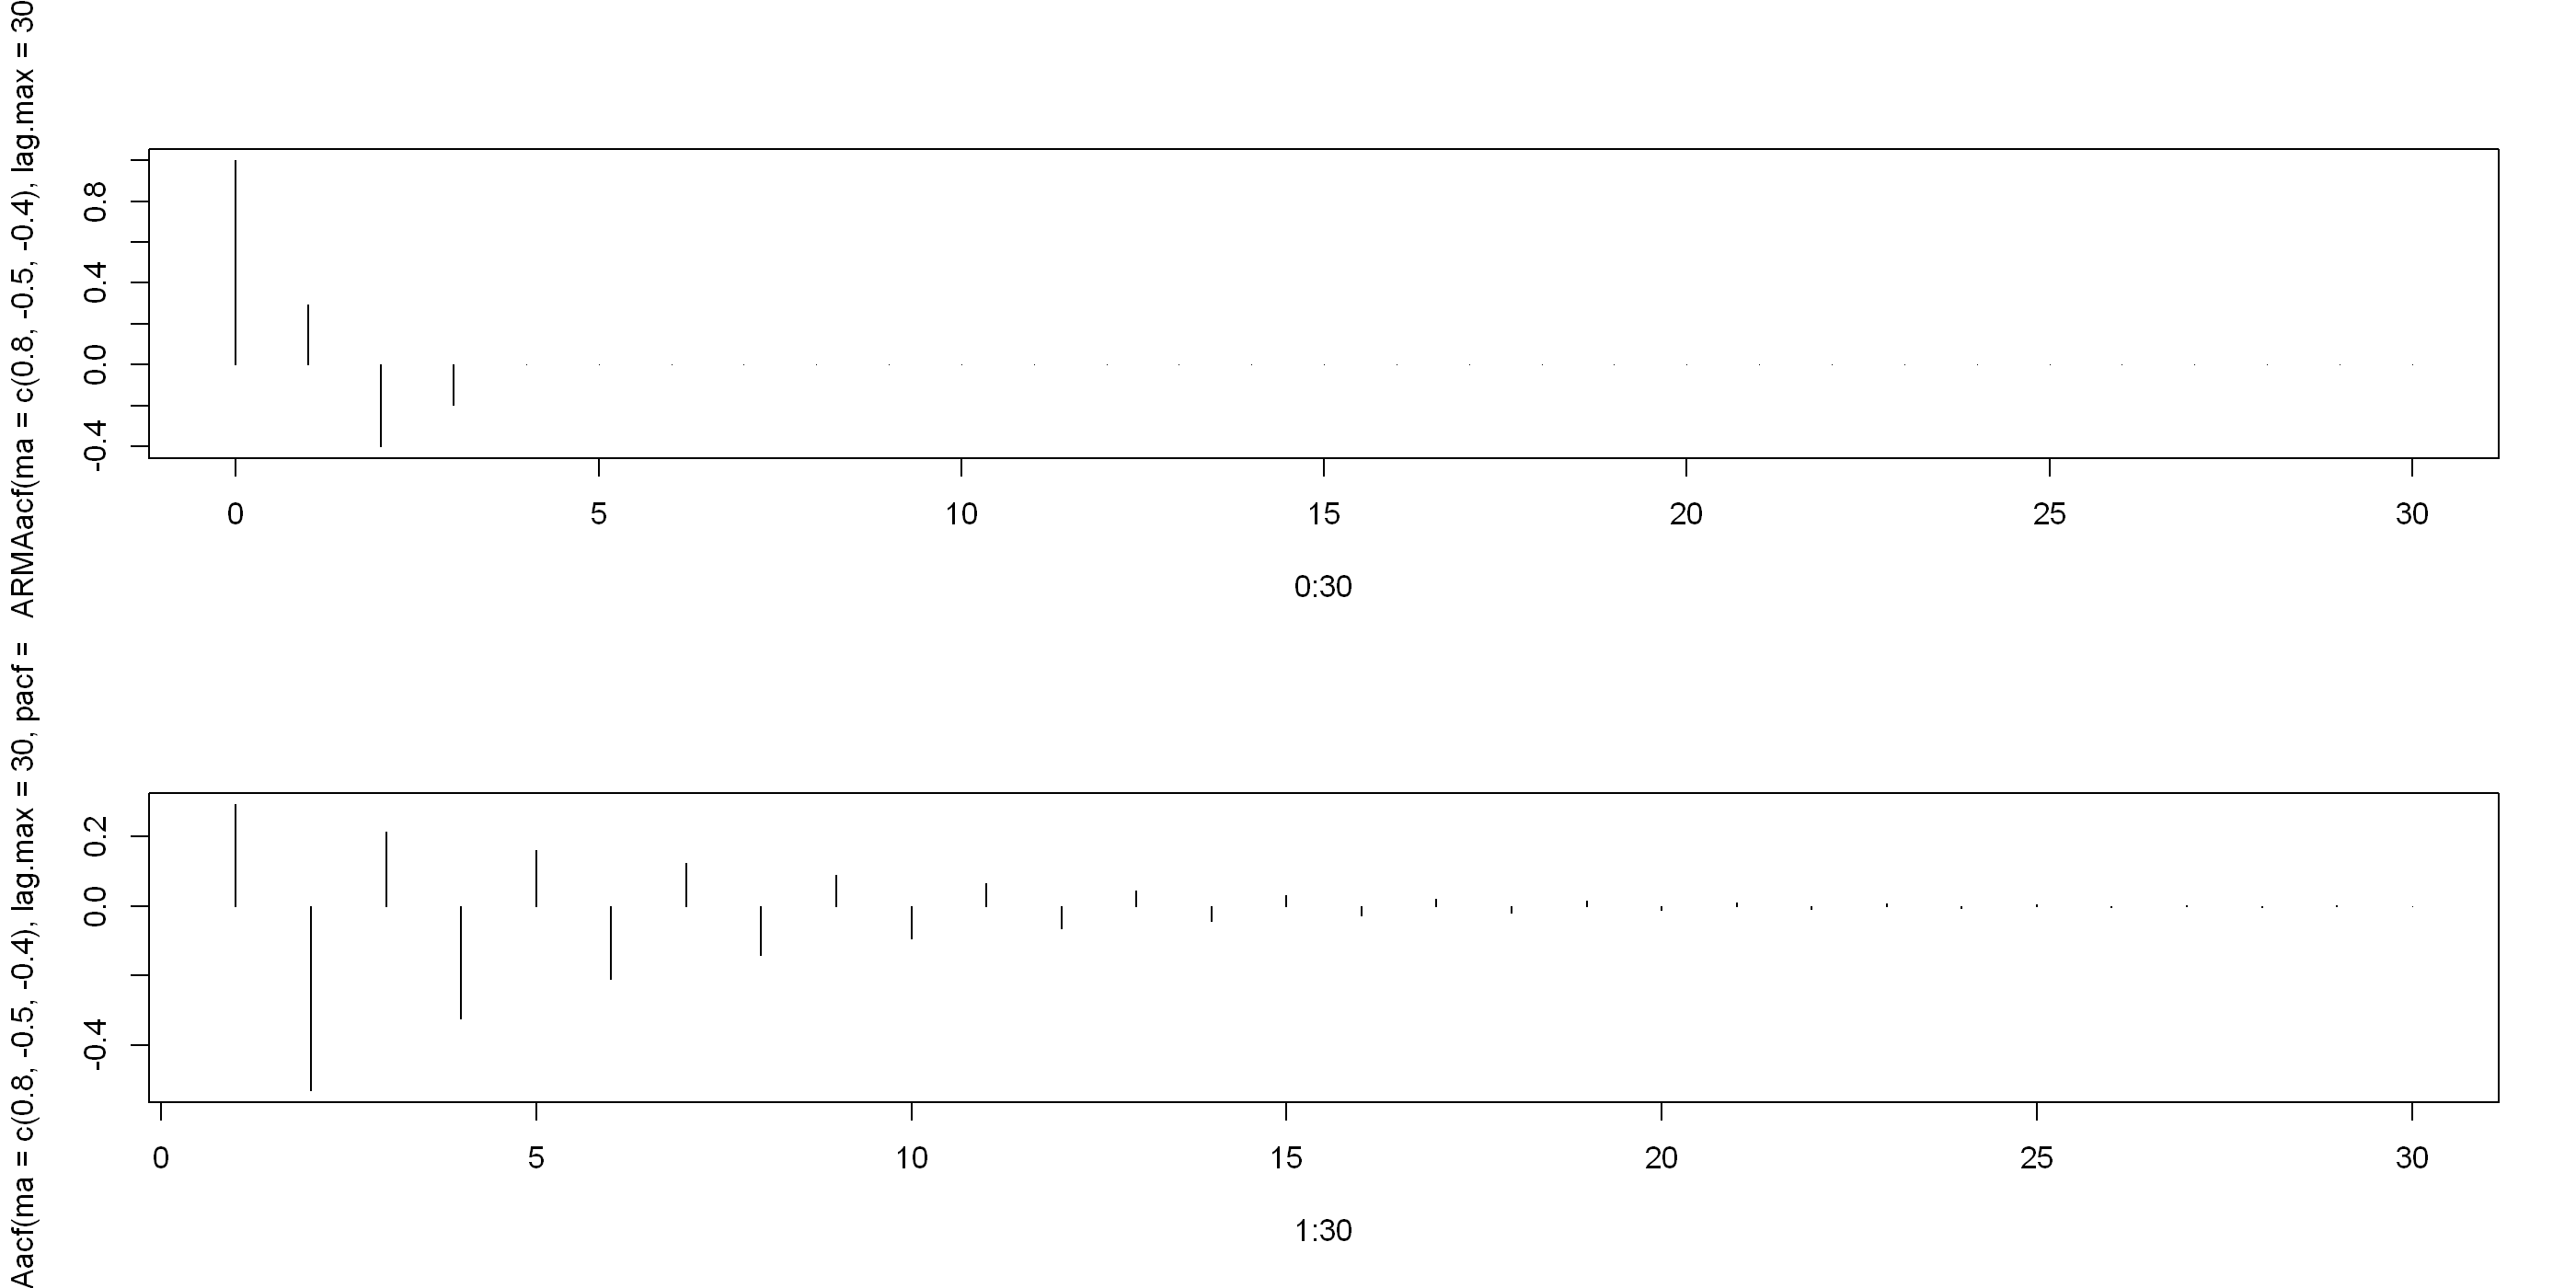

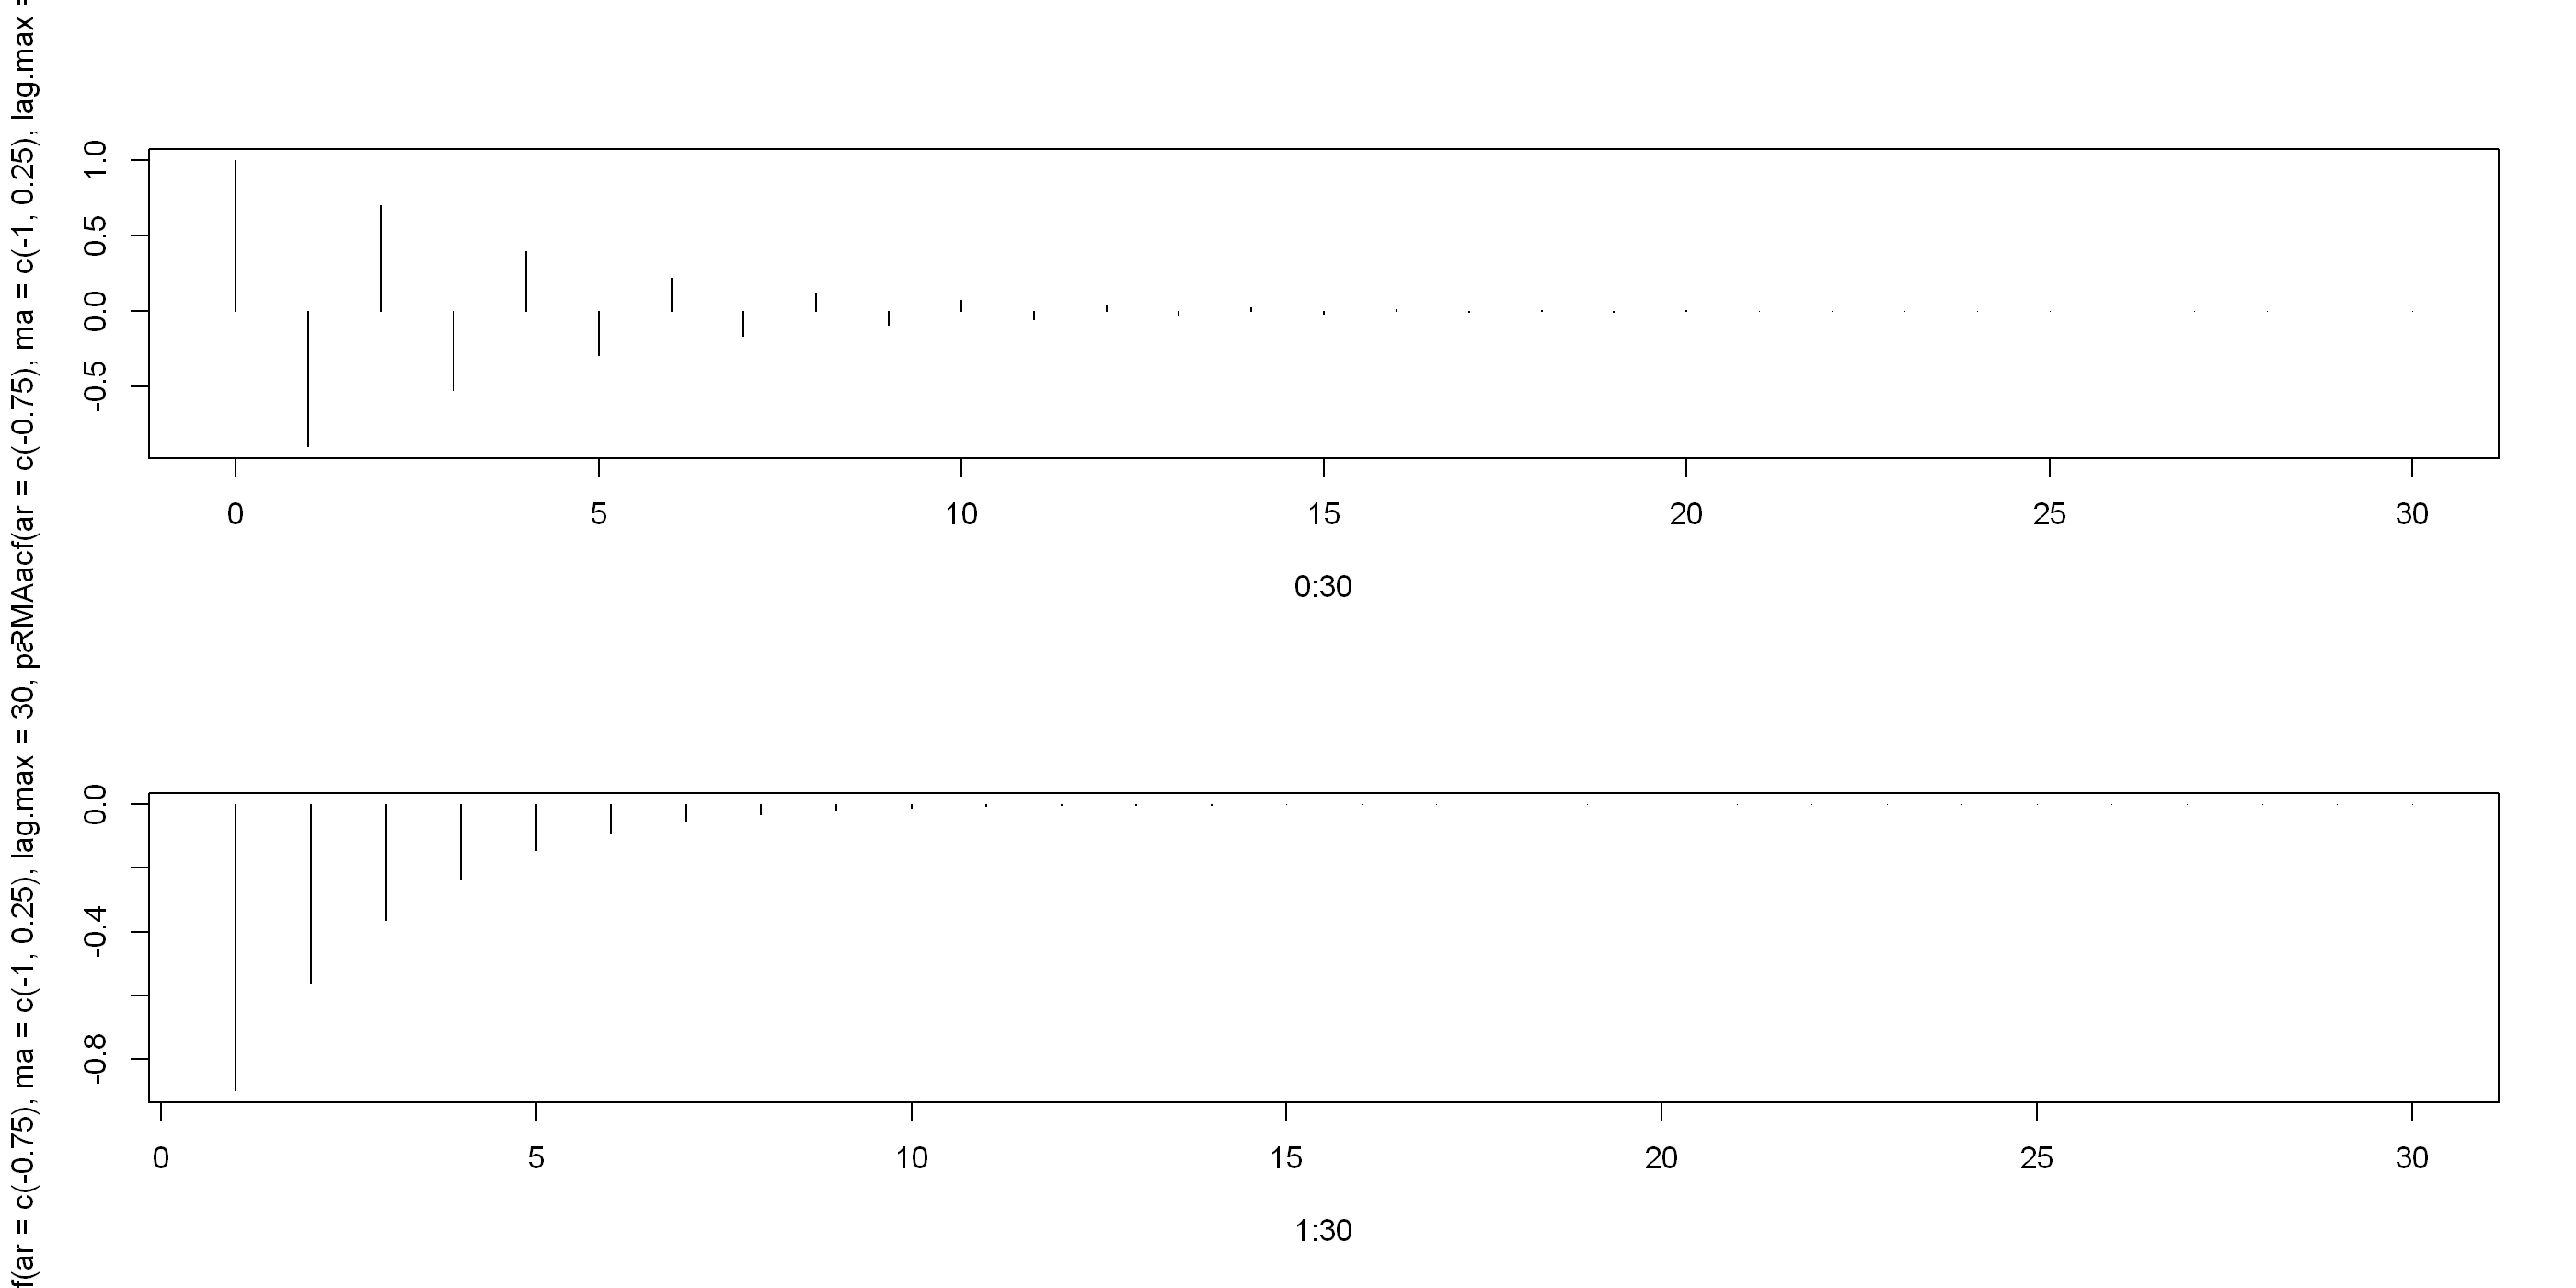

In [14]:
par(mfrow = c(2,1))
plot(0:30,ARMAacf(ar=c(0.9,-0.5),lag.max = 30),type="h")
plot(1:30,ARMAacf(ar=c(0.9,-0.5),lag.max = 30,pacf = TRUE),type="h")


par(mfrow = c(2,1))
plot(0:30,ARMAacf(ma=c(0.8,-0.5,-0.4),lag.max = 30),type="h")
plot(1:30,ARMAacf(ma=c(0.8,-0.5,-0.4),lag.max = 30,pacf = TRUE),type="h")

par(mfrow = c(2,1))
plot(0:30,ARMAacf(ar=c(-0.75),ma = c(-1,0.25),lag.max = 30),type="h")
plot(1:30,ARMAacf(ar=c(-0.75),ma = c(-1,0.25),lag.max = 30,pacf = TRUE),type="h")


In [15]:
# AR_2 <- function(coefs,n)
# {
#     E = rnorm(n = n,mean = 0,sd = 1)
#     X = numeric(n)
#     X[1] = E[1]

#     X[2] = coefs[1]*X[1]+E[2]
    
#     for(t in 3:n)
#     {
#         X[t] = coefs[1]*X[t-1]+coefs[2]*X[t-2]+E[t]
#     }
#     ts(X)
# }

# X_ar2 <- AR_2(c(0.9,-0.5),n = 200)

# plot(X_ar2)

In [16]:
options(repr.plot.width = 16, repr.plot.height = 9, repr.plot.res = 200)


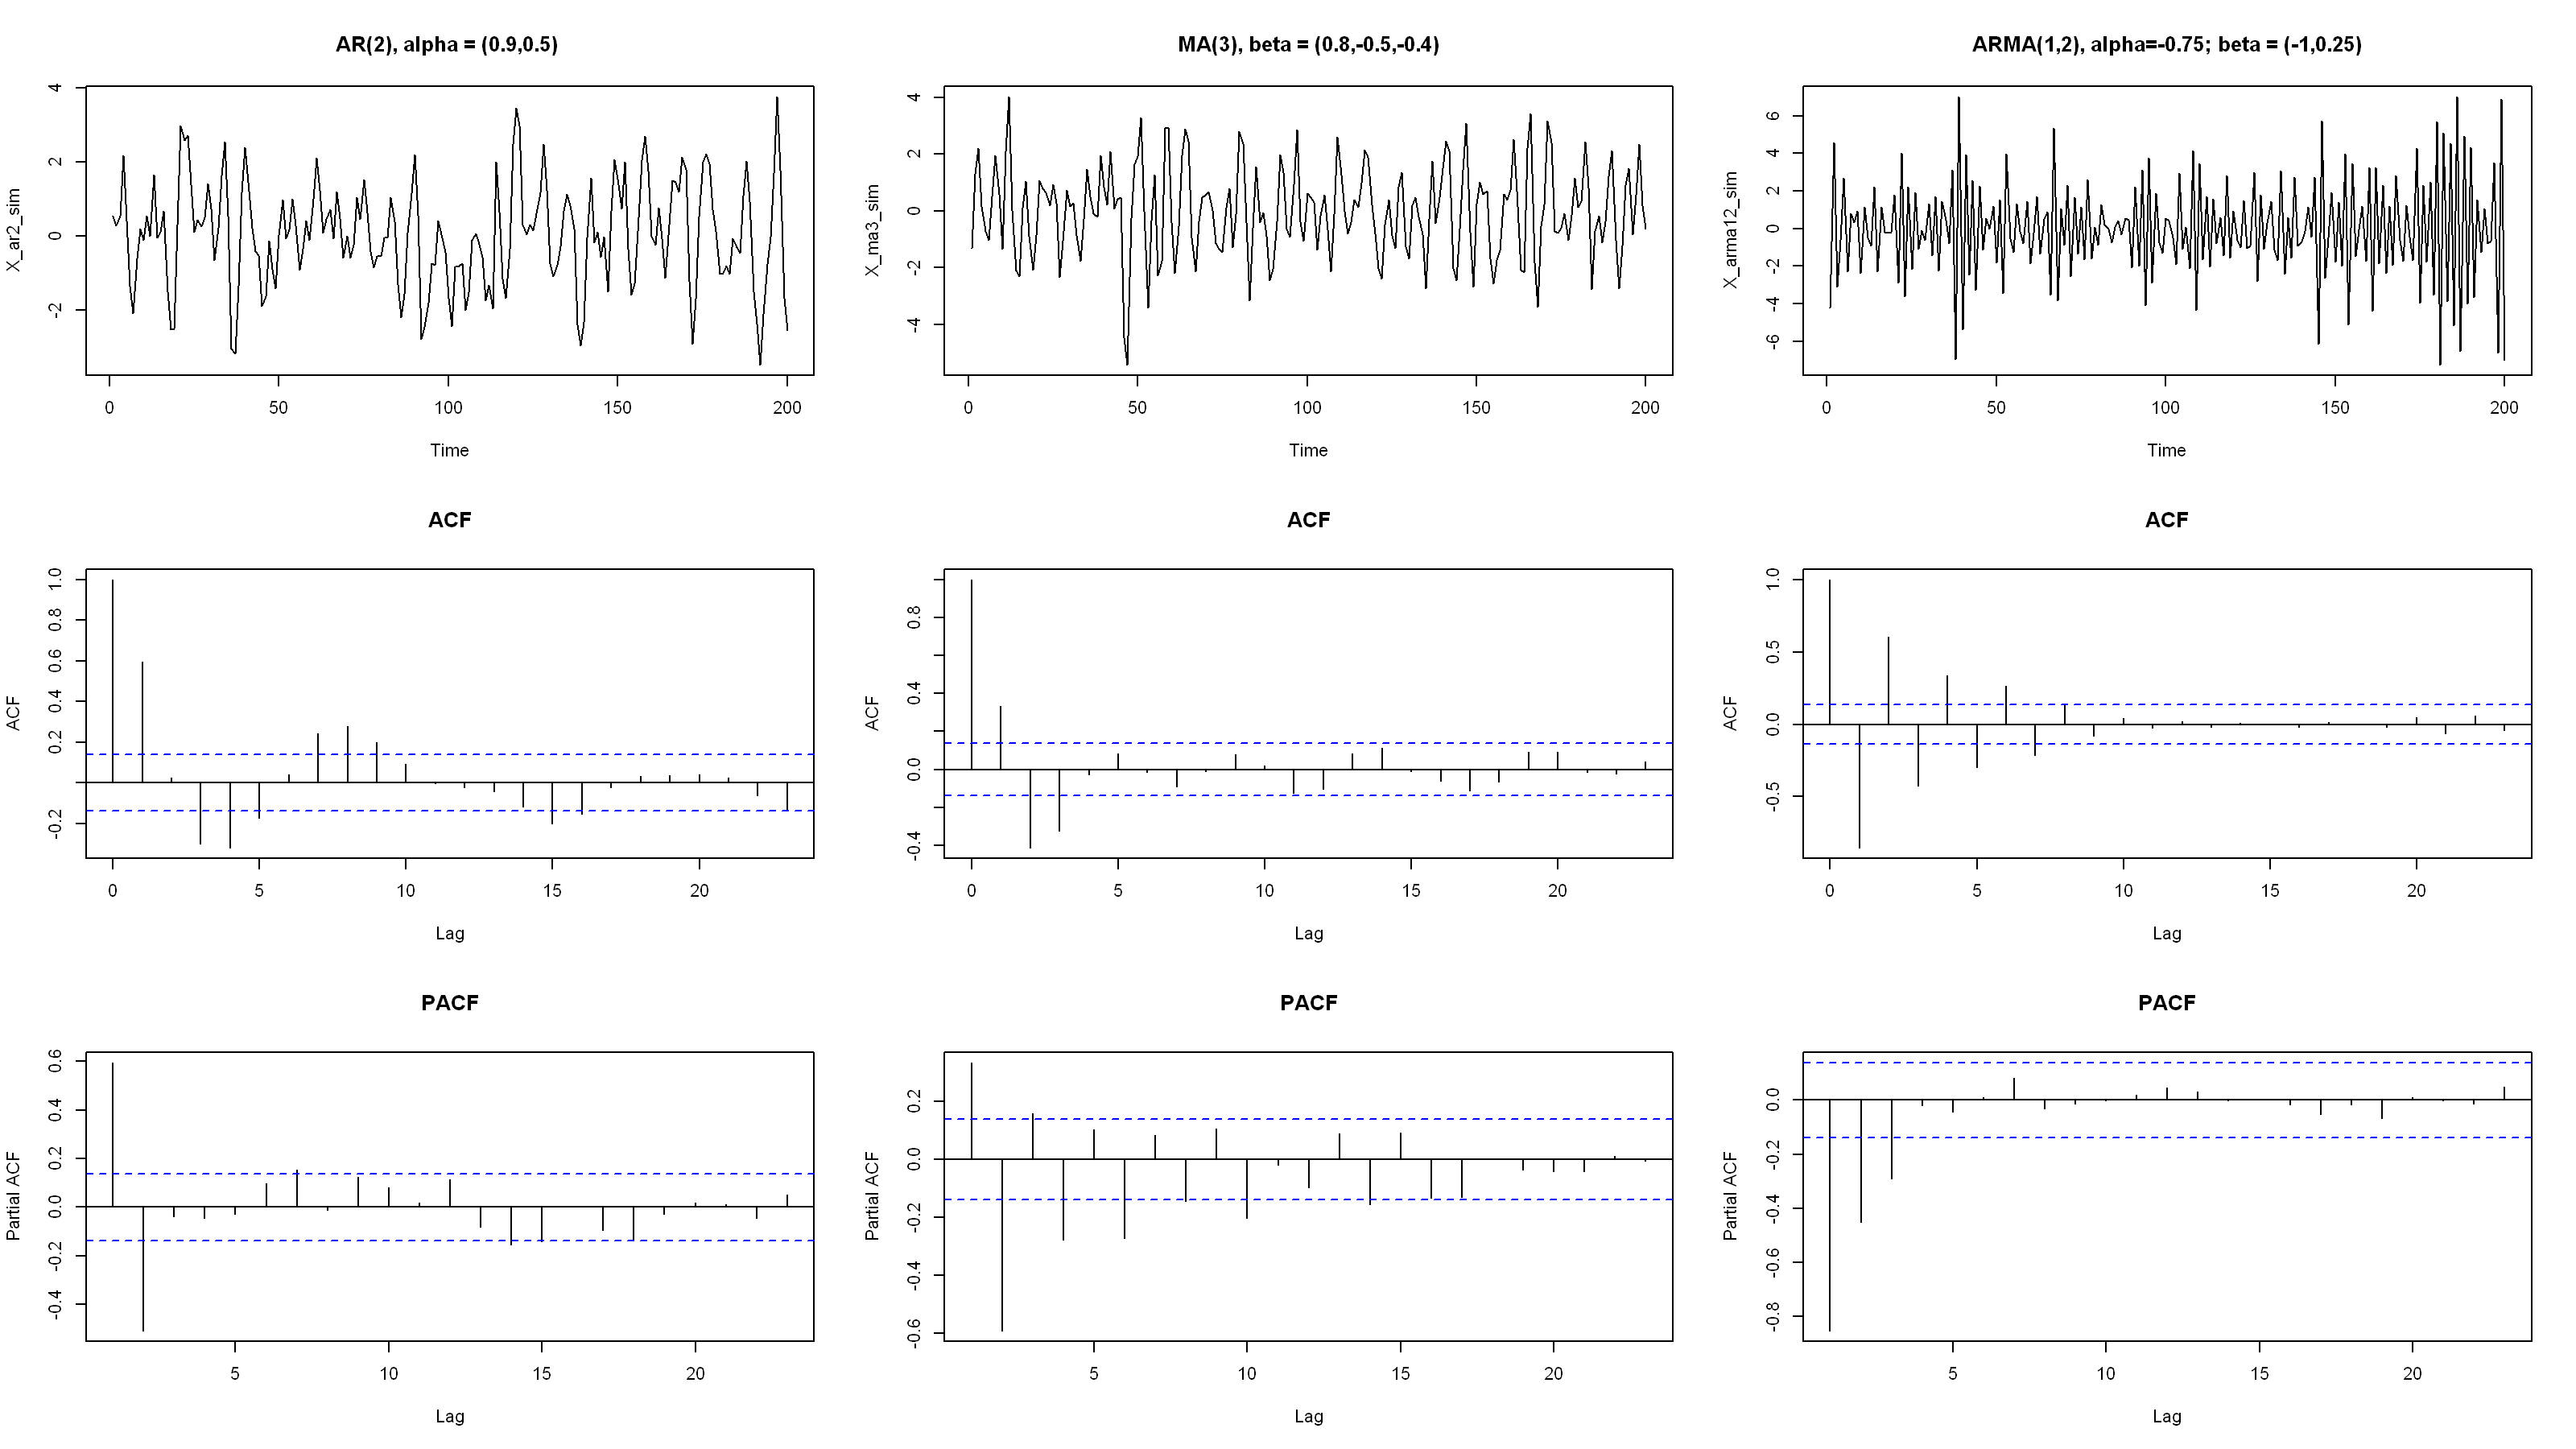

In [17]:
X_ar2_sim = arima.sim(list(ar=c(0.9,-0.5)),n = 200)
X_ma3_sim = arima.sim(list(ma=c(0.8,-0.5,-0.4)),n=200)
X_arma12_sim = arima.sim(list(ma=c(-1,0.25),ar=c(-0.75)),n=200)

par(mfrow = c(3,3))
plot(X_ar2_sim,main="AR(2), alpha = (0.9,0.5) ")
plot(X_ma3_sim,main="MA(3), beta = (0.8,-0.5,-0.4)")
plot(X_arma12_sim,main="ARMA(1,2), alpha=-0.75; beta = (-1,0.25)")

acf(X_ar2_sim,main="ACF")
acf(X_ma3_sim,main="ACF")
acf(X_arma12_sim,main="ACF")

pacf(X_ar2_sim,main="PACF")
pacf(X_ma3_sim,main="PACF")
pacf(X_arma12_sim,main="PACF")


### 4.3


![ex4_3](ex4_3.png)

In [18]:
dat<-read.table("http://stat.ethz.ch/Teaching/Datasets/WBL/mcARMA.dat",header = TRUE)
ts<-ts(dat$x)

##### a

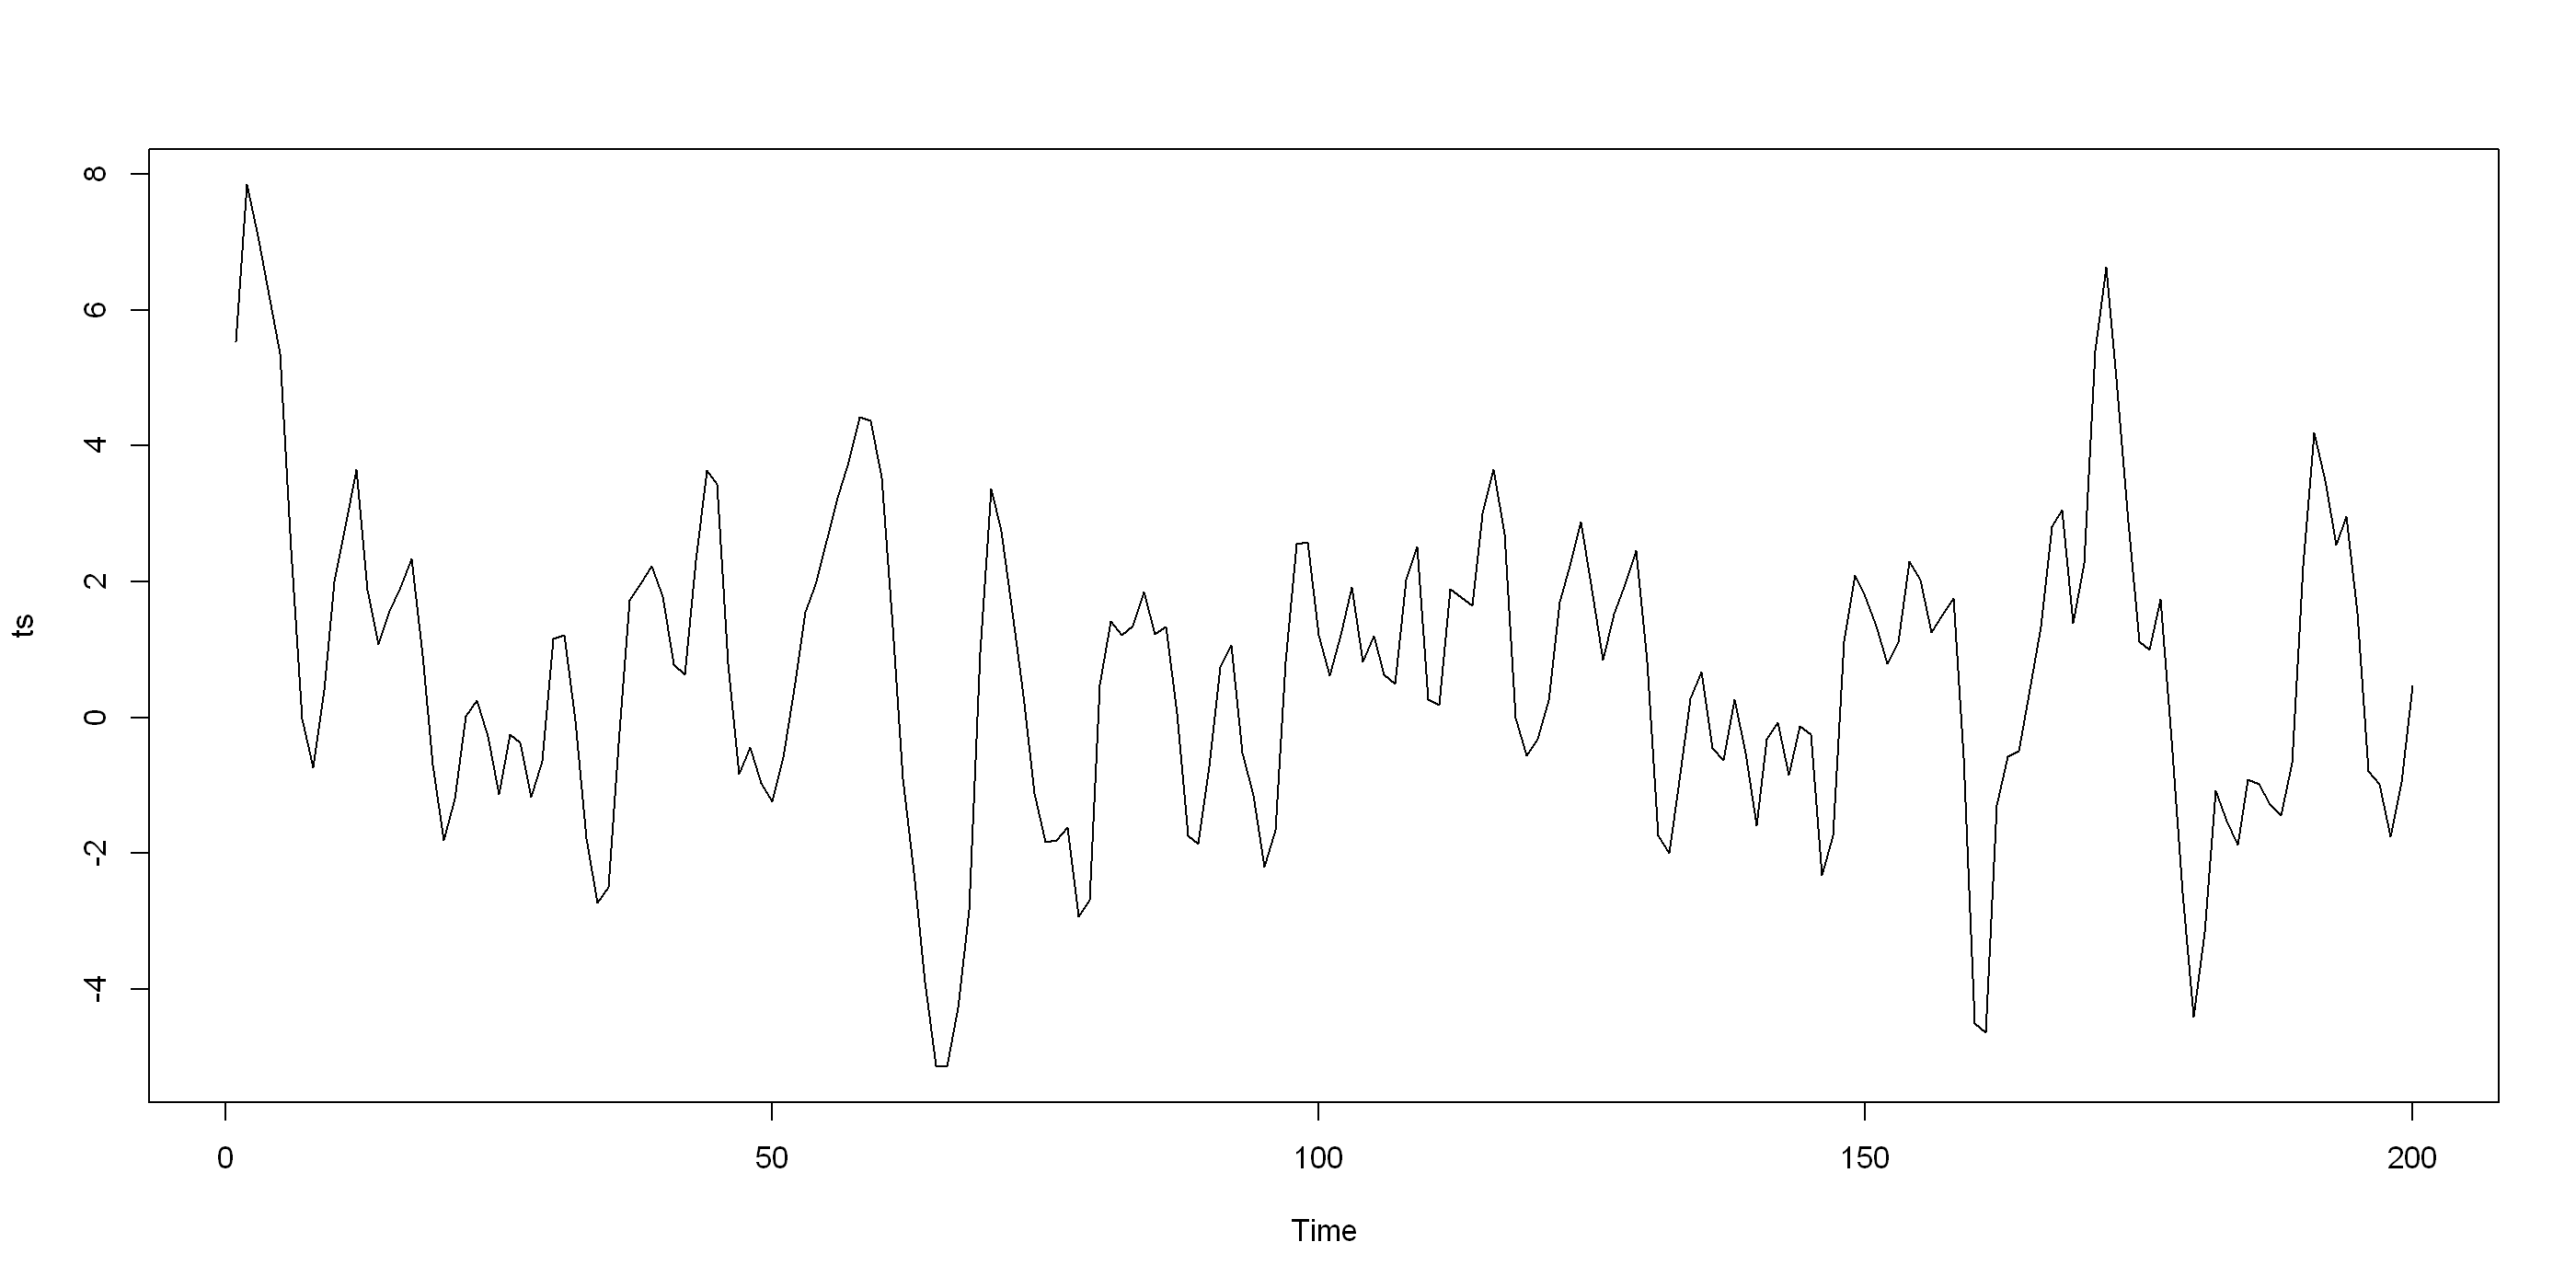

In [19]:
options(repr.plot.width = 14, repr.plot.height = 7, repr.plot.res = 200)

plot(ts)

Roughly speaking, yes it could be stationary, the mean is roughly constant and same goes for the variance, further there is no clear trend nor seasonality hence we don't have enough evidence to reject stationarity, we simply claim the series is weakly stationary.

##### b

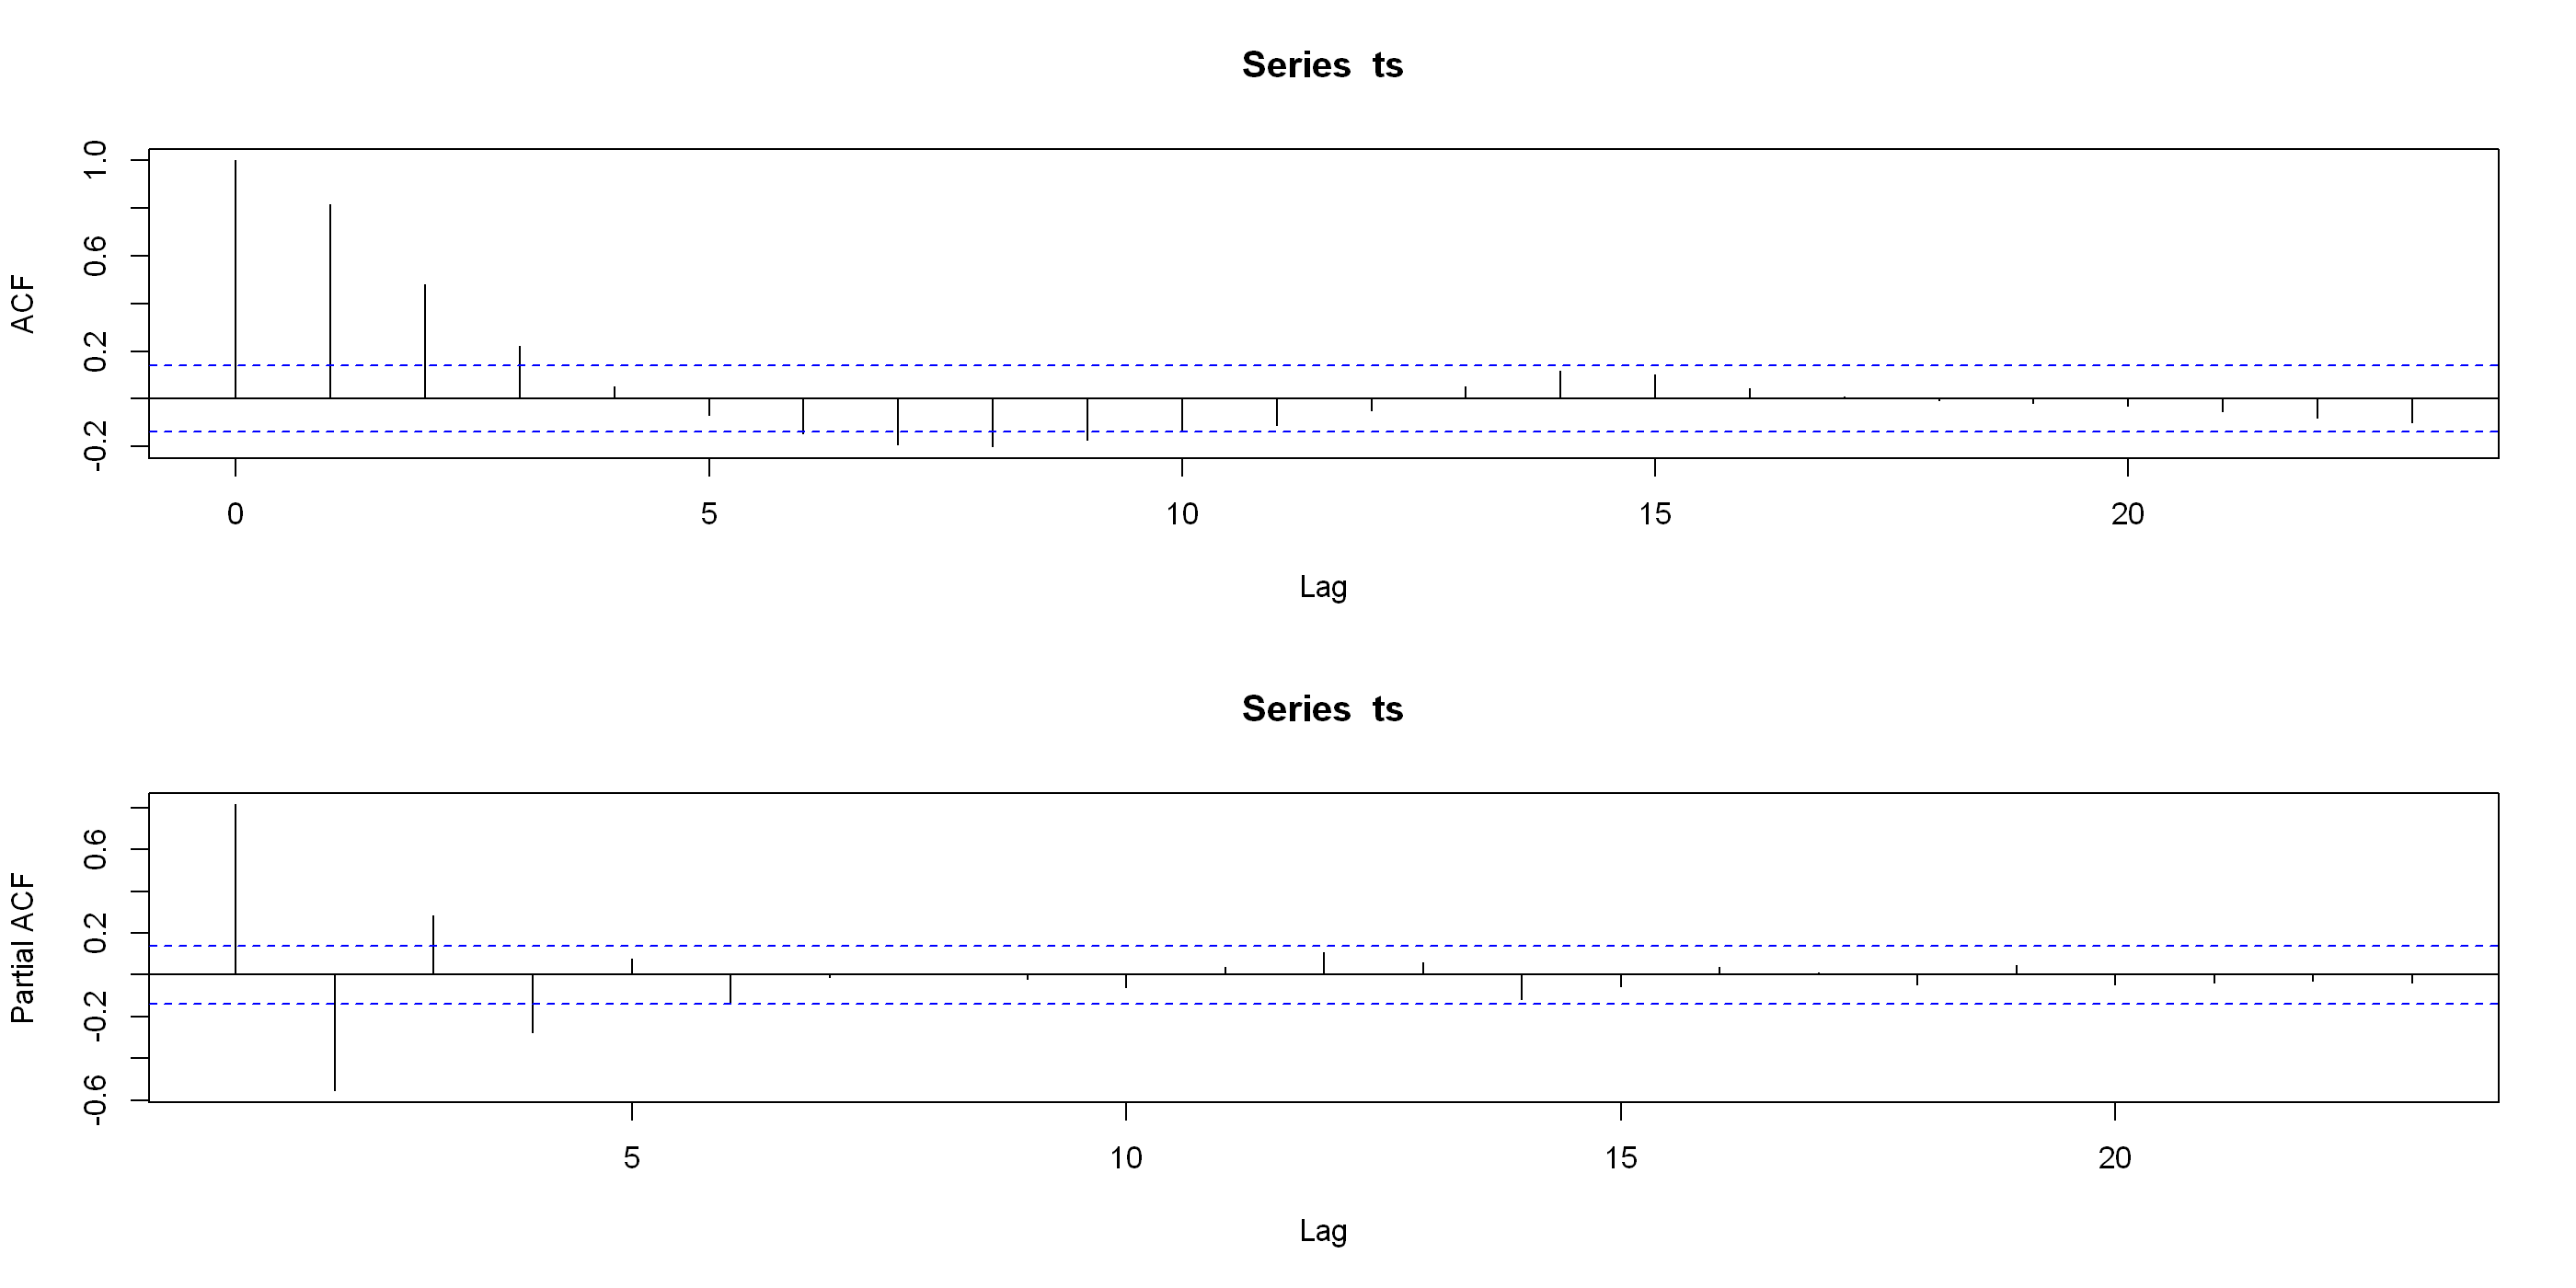

In [20]:
par(mfrow = c(2,1))
acf(ts)
pacf(ts)

In the same setting as before, we would argue that since there is an exponential decay in the ACF and roughly a cut-off like behaviour in the PACF a ARMA model with a dominating AR term would be appropriate, we would likely pick or less $p=6$, and possibly or larger $q=1$, this needs to be verified ofcourse. Notably since the suggestion is to pick fewer parameters we experiment with AR,MA,ARMA models on $(q,p)\in \{1,...,6\}^2$.

In [21]:
end = 6
AR_p = vector(mode = "list",length = end)
MA_q = vector(mode = "list",length = end)
ARMA_pq = vector(mode = "list",length = end**2)

labels_AR_p = vector(mode = "list",length = end)
labels_MA_q = vector(mode = "list",length = end)
labels_ARMA_pq = vector(mode = "list",length = end**2)



AIC_AR_p = numeric(end)
AIC_MA_q = numeric(end)
AIC_ARMA_pq = numeric(end**2)

for(i in 1:end)
{
    AR_p[[i]] = arima(ts,order = c(i,0,0),method = "ML")
    AIC_AR_p[i] = AR_p[[i]]$aic
    labels_AR_p[[i]] = paste0("AR(",i,")")
    MA_q[[i]] = arima(ts,order = c(0,0,i),method = "ML")
    AIC_MA_q[i] = MA_q[[i]]$aic
    labels_MA_q[[i]] = paste0("MA(",i,")")

    for(j in 1:end)
    {
        k = j+(i-1)*end
       
        ARMA_pq[[k]] = arima(ts,order = c(i,0,j),method = "ML") 
        labels_ARMA_pq[[k]] = paste0("ARMA(",i,",",j,")")
        AIC_ARMA_pq[k] = ARMA_pq[[k]]$aic
    }
}



Warning message in arima(ts, order = c(i, 0, j), method = "ML"):
"possible convergence problem: optim gave code = 1"
Warning message in arima(ts, order = c(i, 0, j), method = "ML"):
"possible convergence problem: optim gave code = 1"
Warning message in arima(ts, order = c(i, 0, j), method = "ML"):
"possible convergence problem: optim gave code = 1"
Warning message in arima(ts, order = c(i, 0, j), method = "ML"):
"possible convergence problem: optim gave code = 1"
Warning message in arima(ts, order = c(i, 0, j), method = "ML"):
"possible convergence problem: optim gave code = 1"
Warning message in arima(ts, order = c(i, 0, j), method = "ML"):
"possible convergence problem: optim gave code = 1"
Warning message in arima(ts, order = c(i, 0, j), method = "ML"):
"possible convergence problem: optim gave code = 1"
Warning message in arima(ts, order = c(i, 0, j), method = "ML"):
"possible convergence problem: optim gave code = 1"
Warning message in arima(ts, order = c(i, 0, j), method = "ML"):

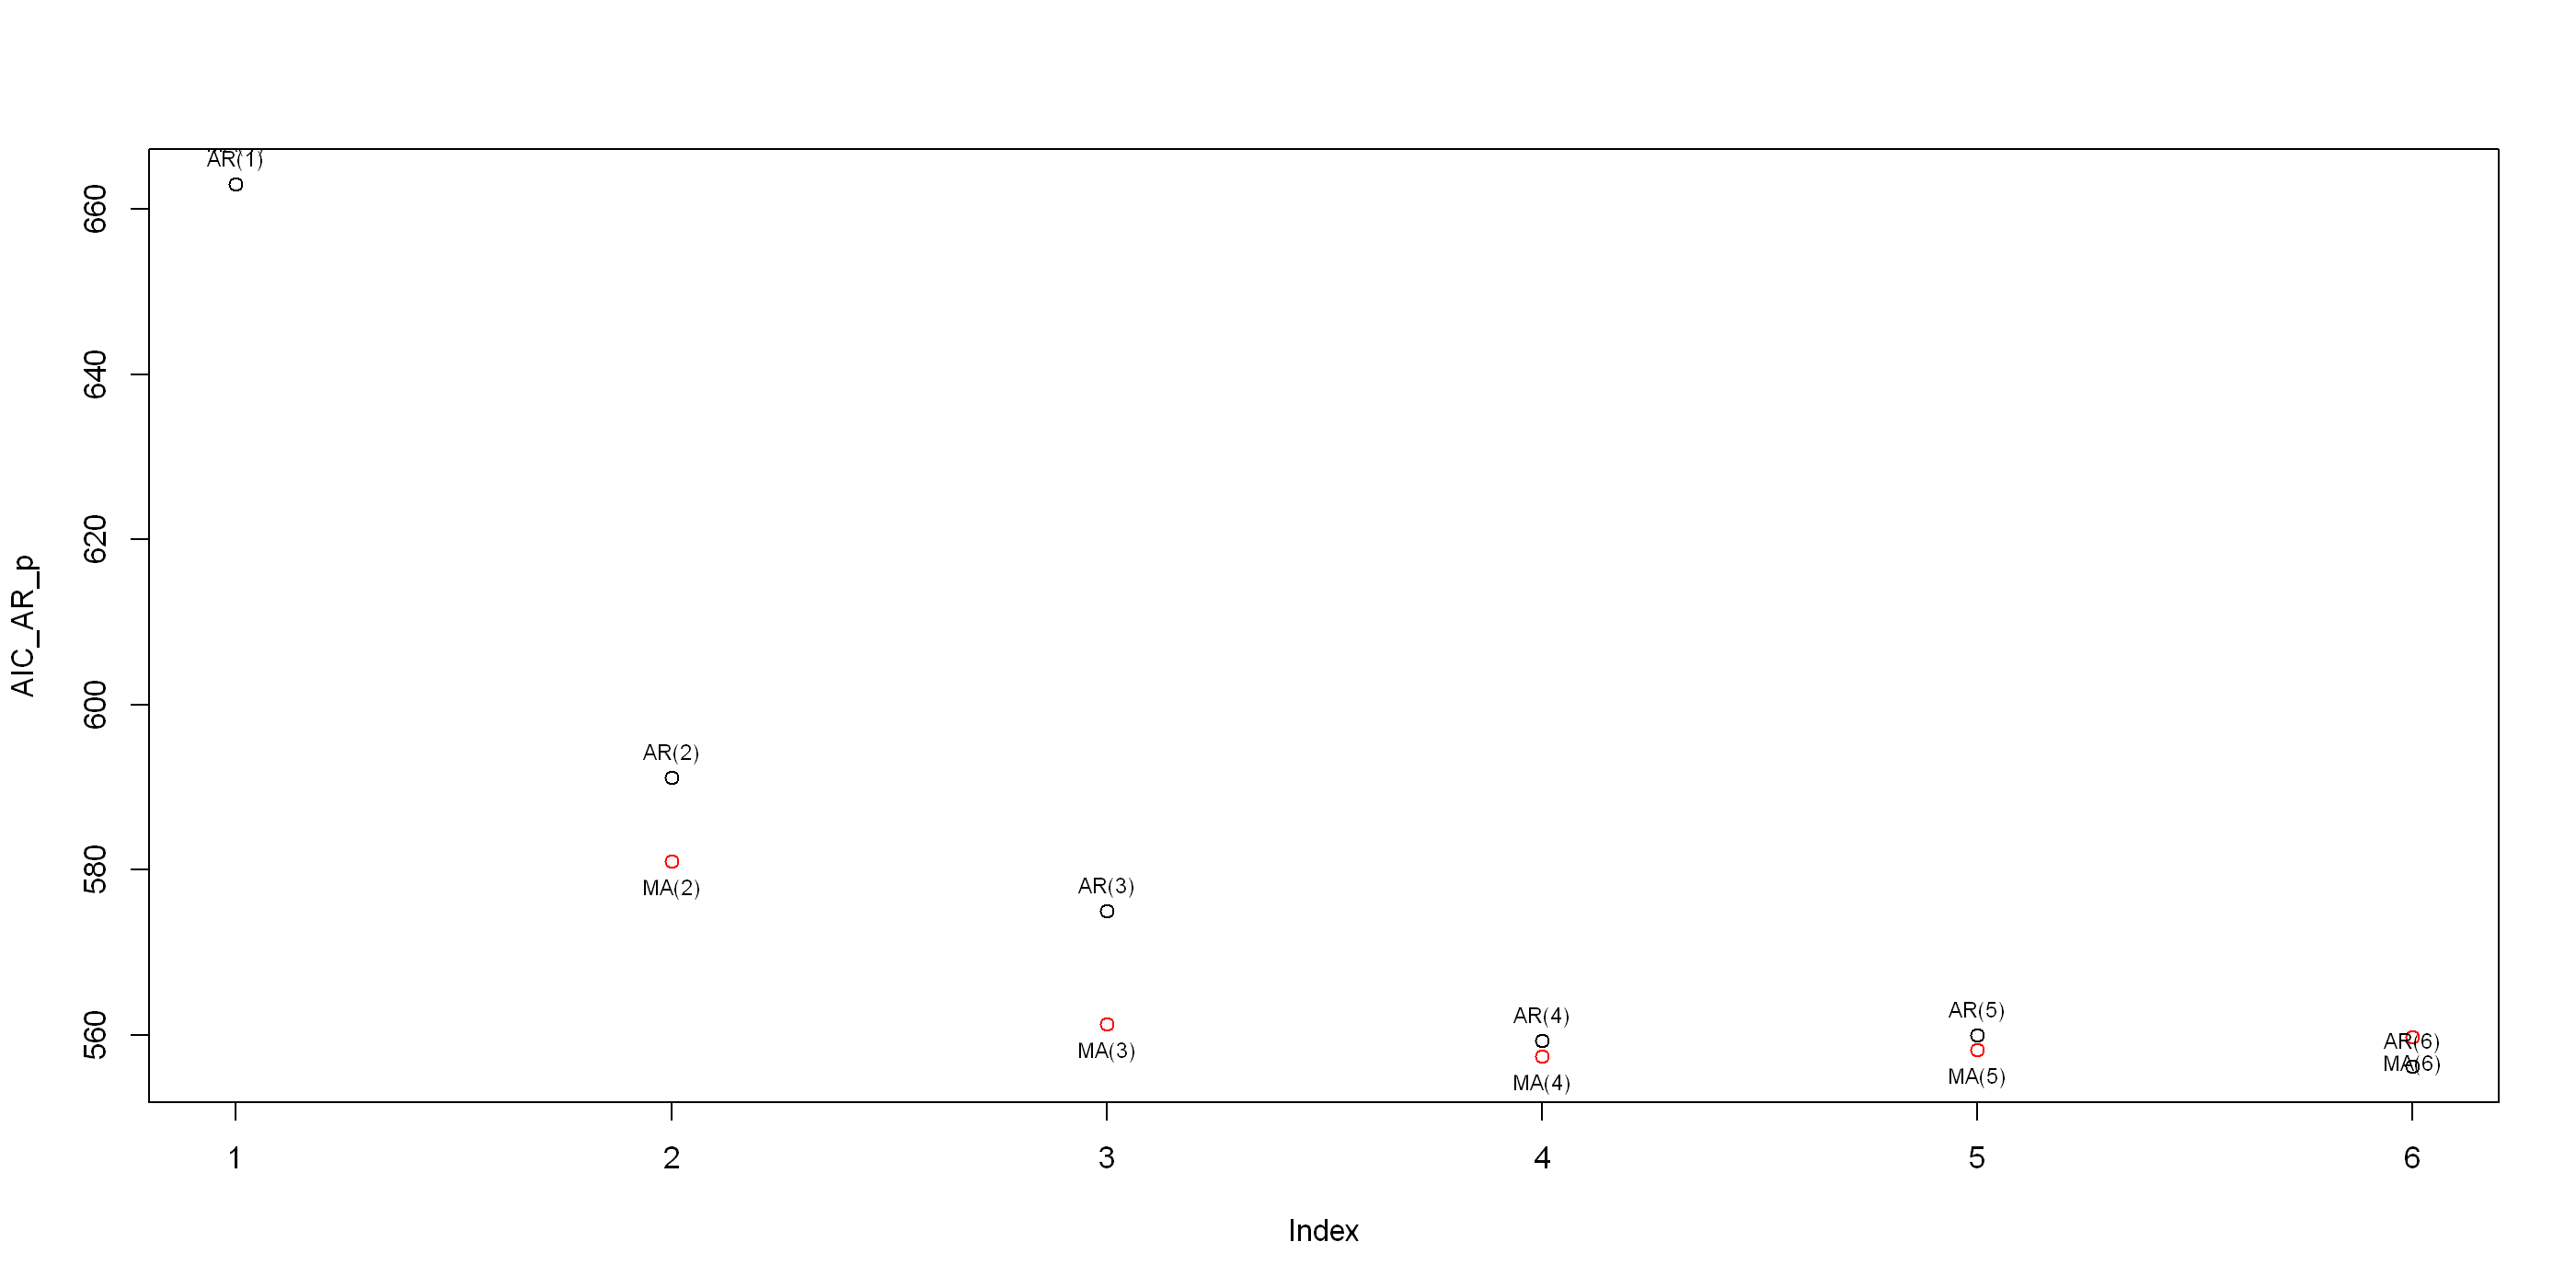

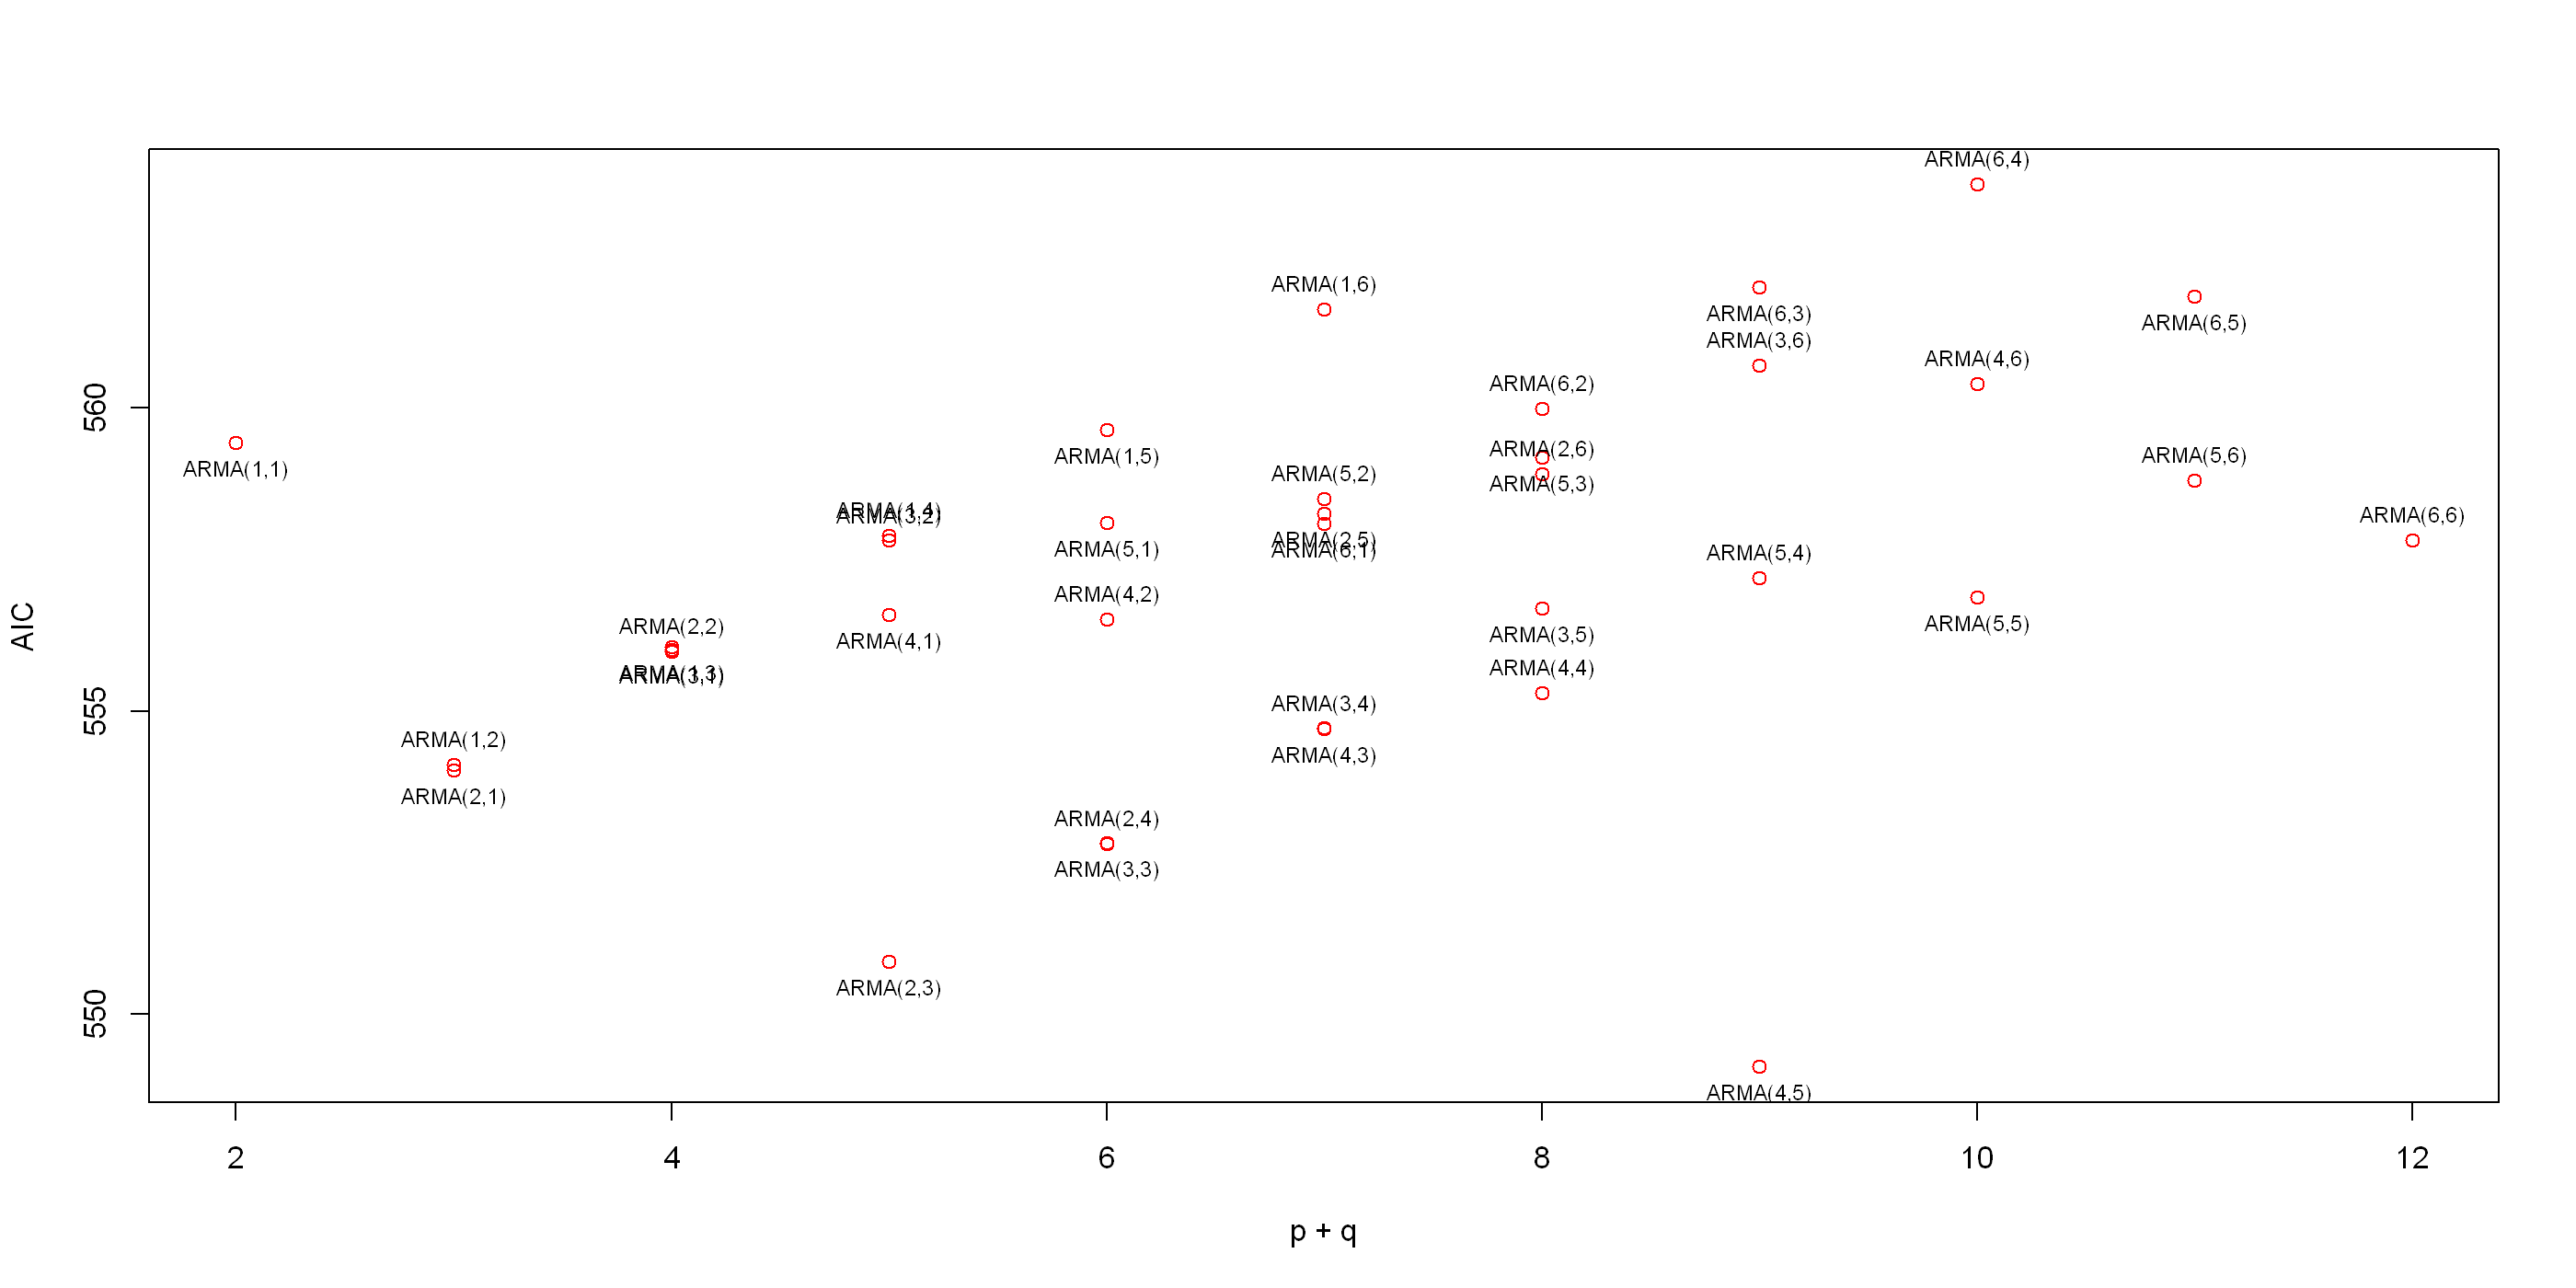

In [22]:
plot(AIC_AR_p, type='p')
points(AIC_MA_q, col='red')
text(1:length(AIC_AR_p), AIC_AR_p, labels=unlist(labels_AR_p), pos=3, cex=0.7)
text(1:length(AIC_MA_q), AIC_MA_q, labels=unlist(labels_MA_q), pos=1, cex=0.7)


pq_sum <- sapply(1:length(ARMA_pq), function(k) {
    p <- ceiling(k / end)
    q <- ((k - 1) %% end) + 1
    p + q
})

pos_vec <- rep(c(1, 3), length.out = length(AIC_ARMA_pq))
plot(pq_sum, AIC_ARMA_pq, col='red', xlab='p + q', ylab='AIC')
text(pq_sum, AIC_ARMA_pq, labels=unlist(labels_ARMA_pq), pos=pos_vec, cex=0.7)


For further analysis we handpick 6 models: ARMA(1,2), ARMA(2,1), ARMA(2,3), ARMA(4,5), AR(6), MA(4)

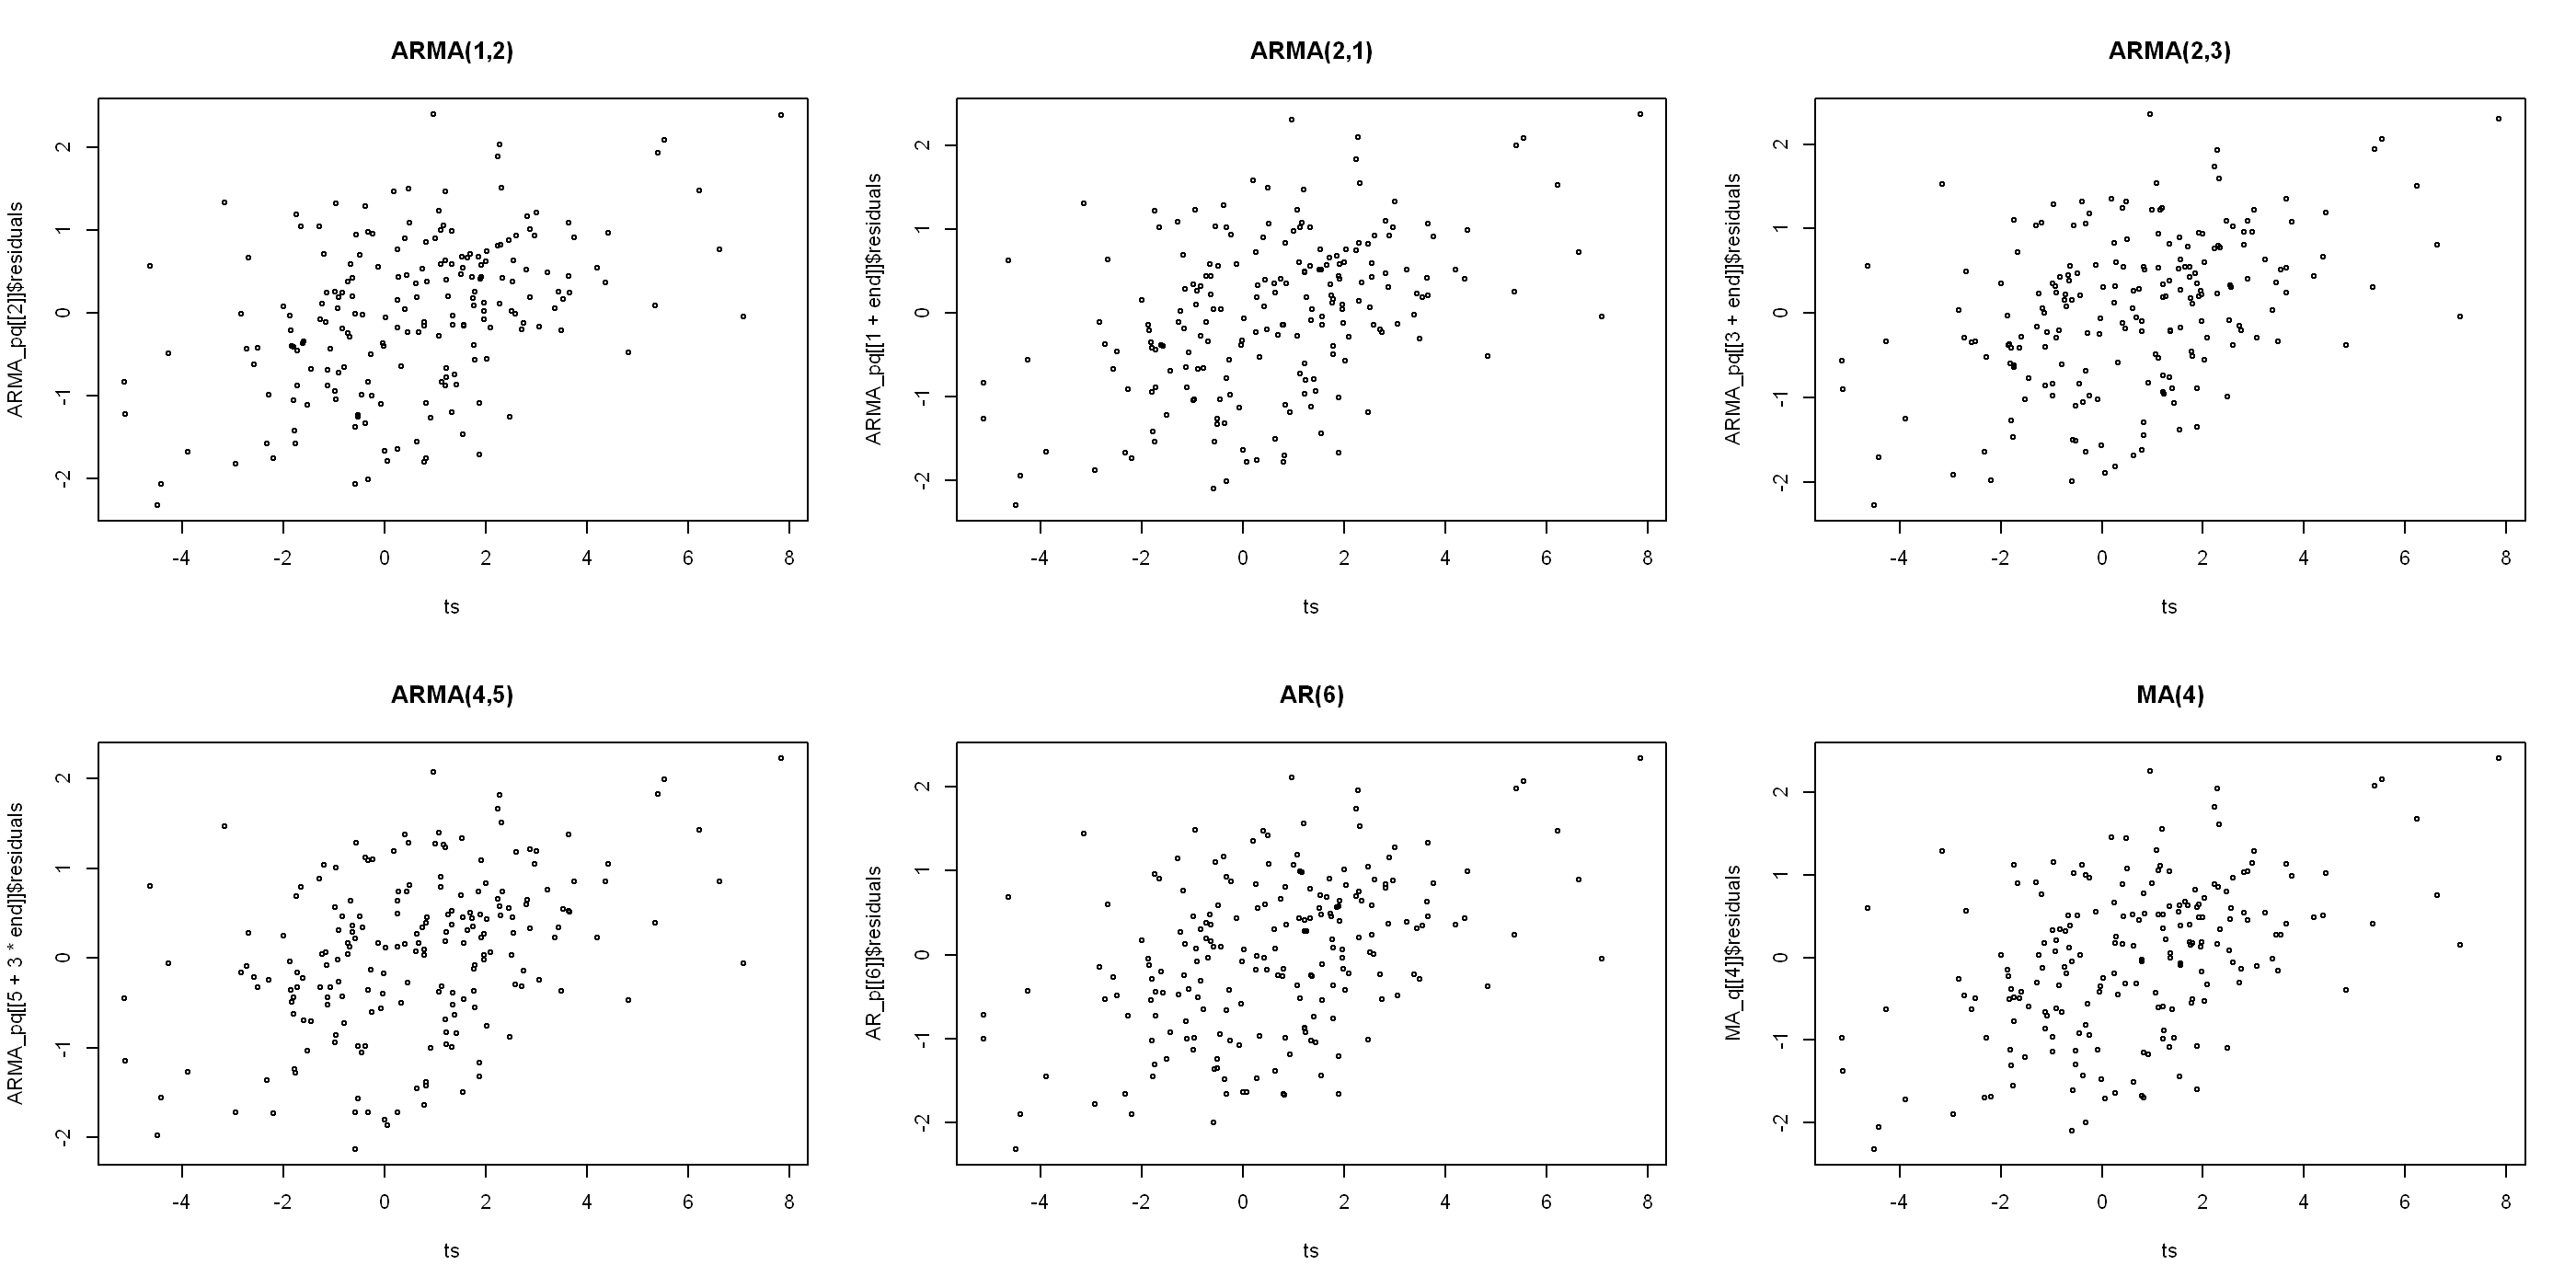

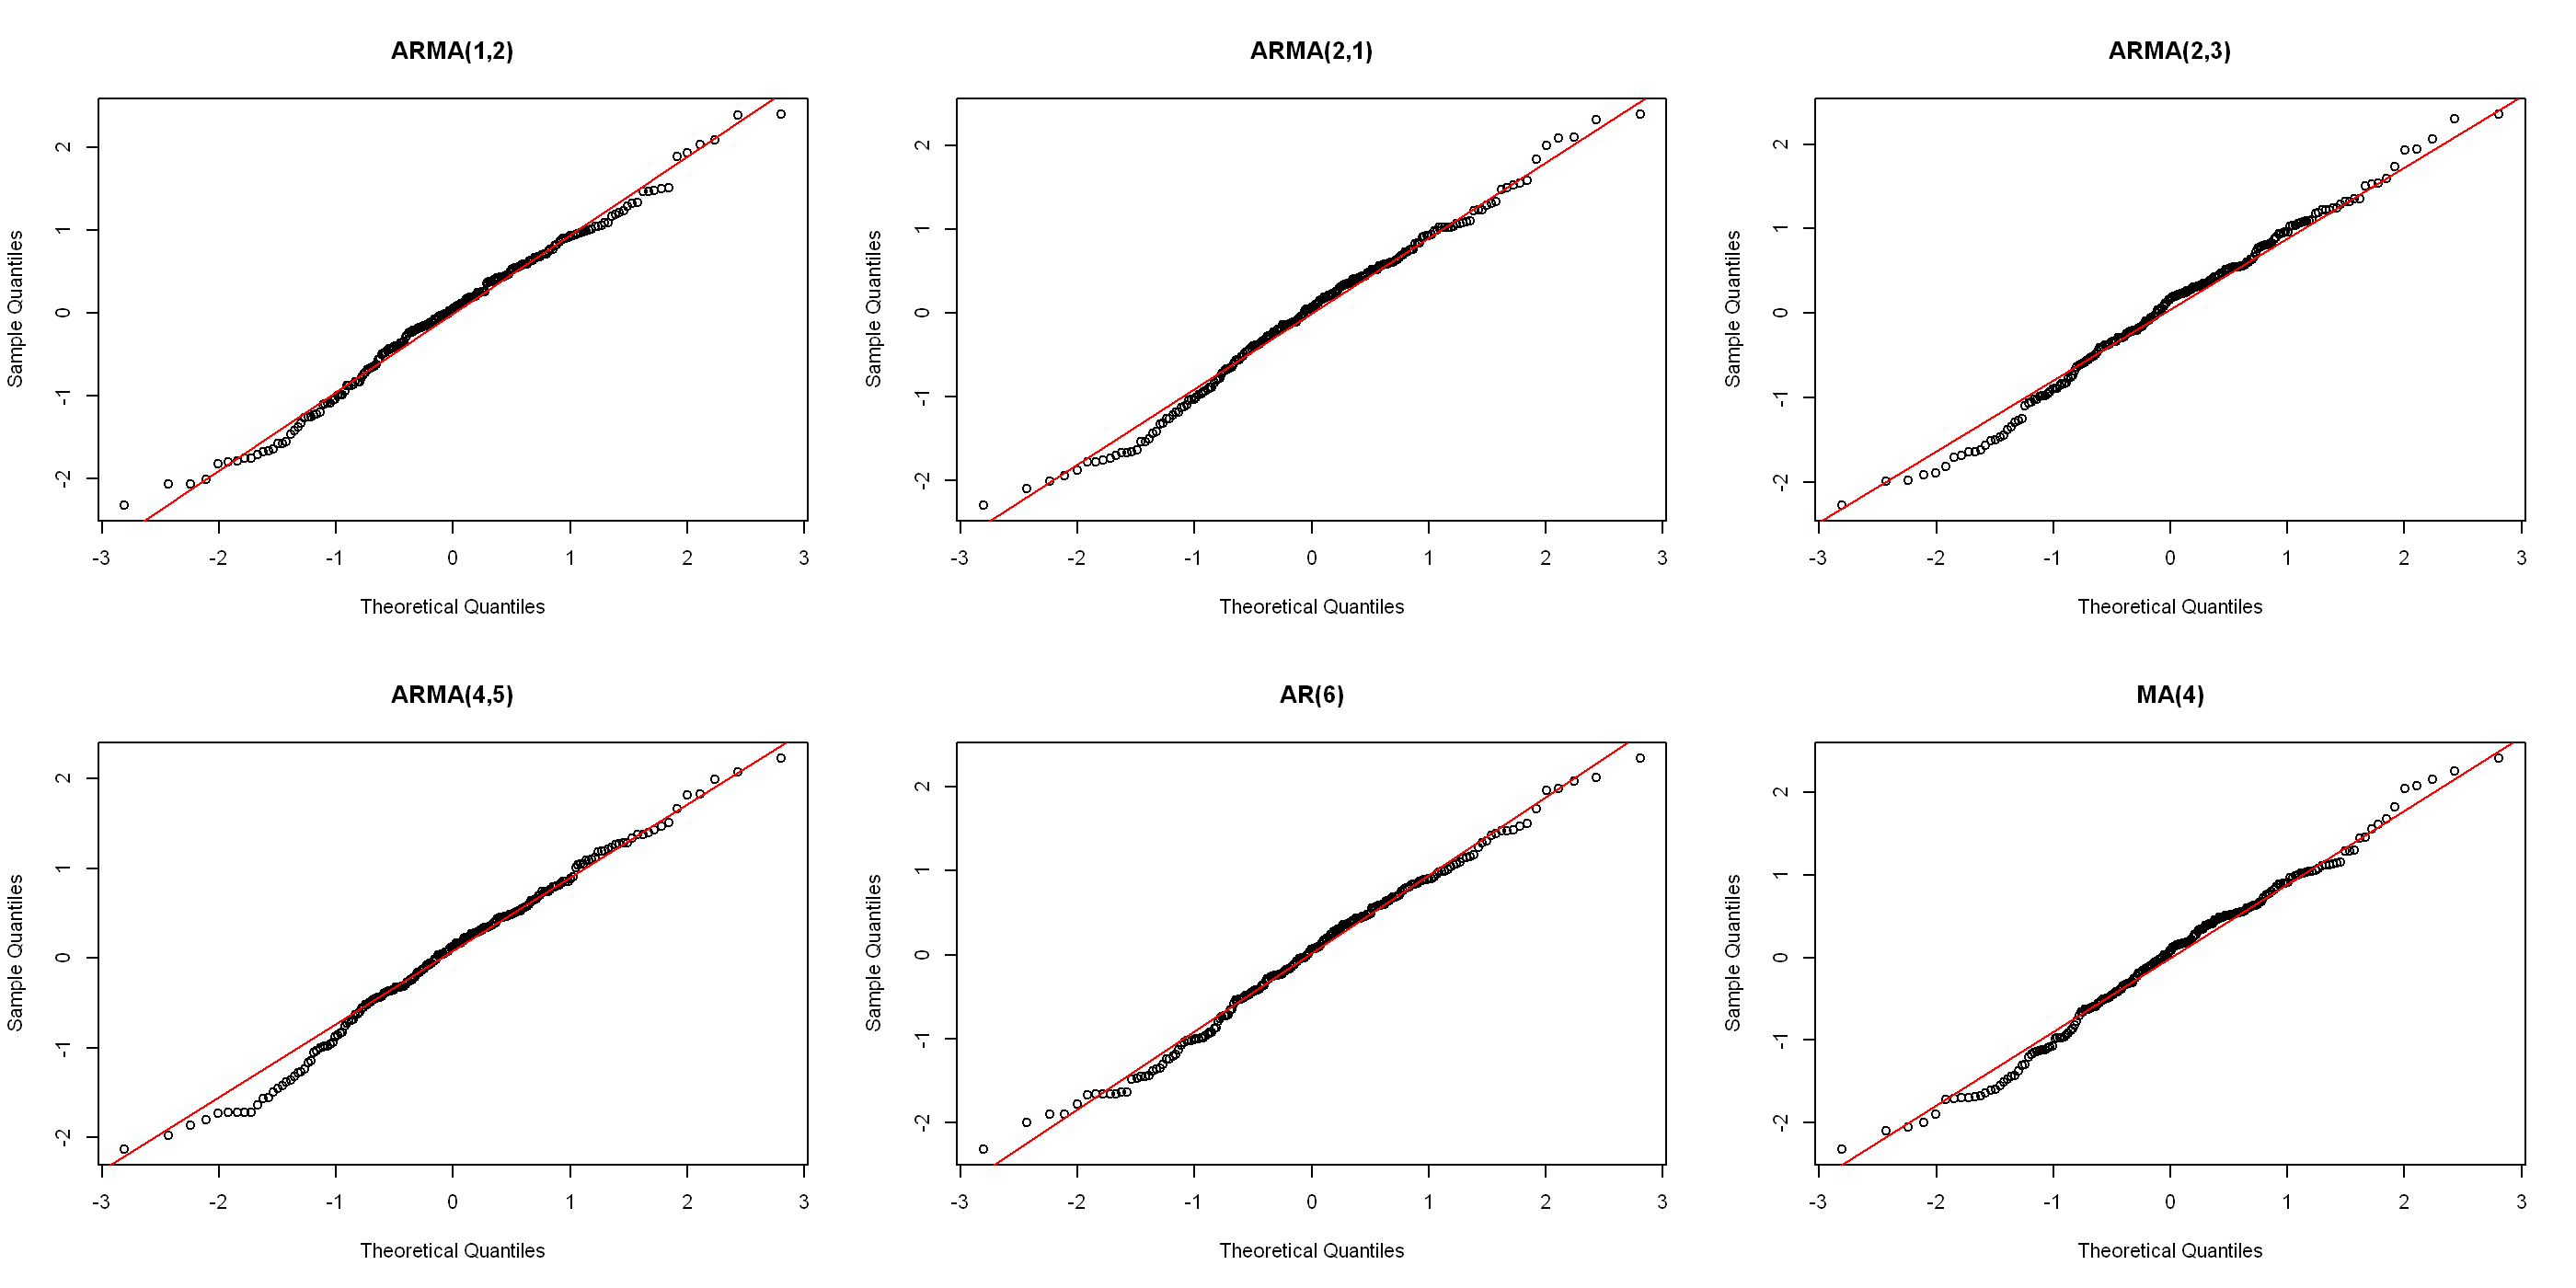

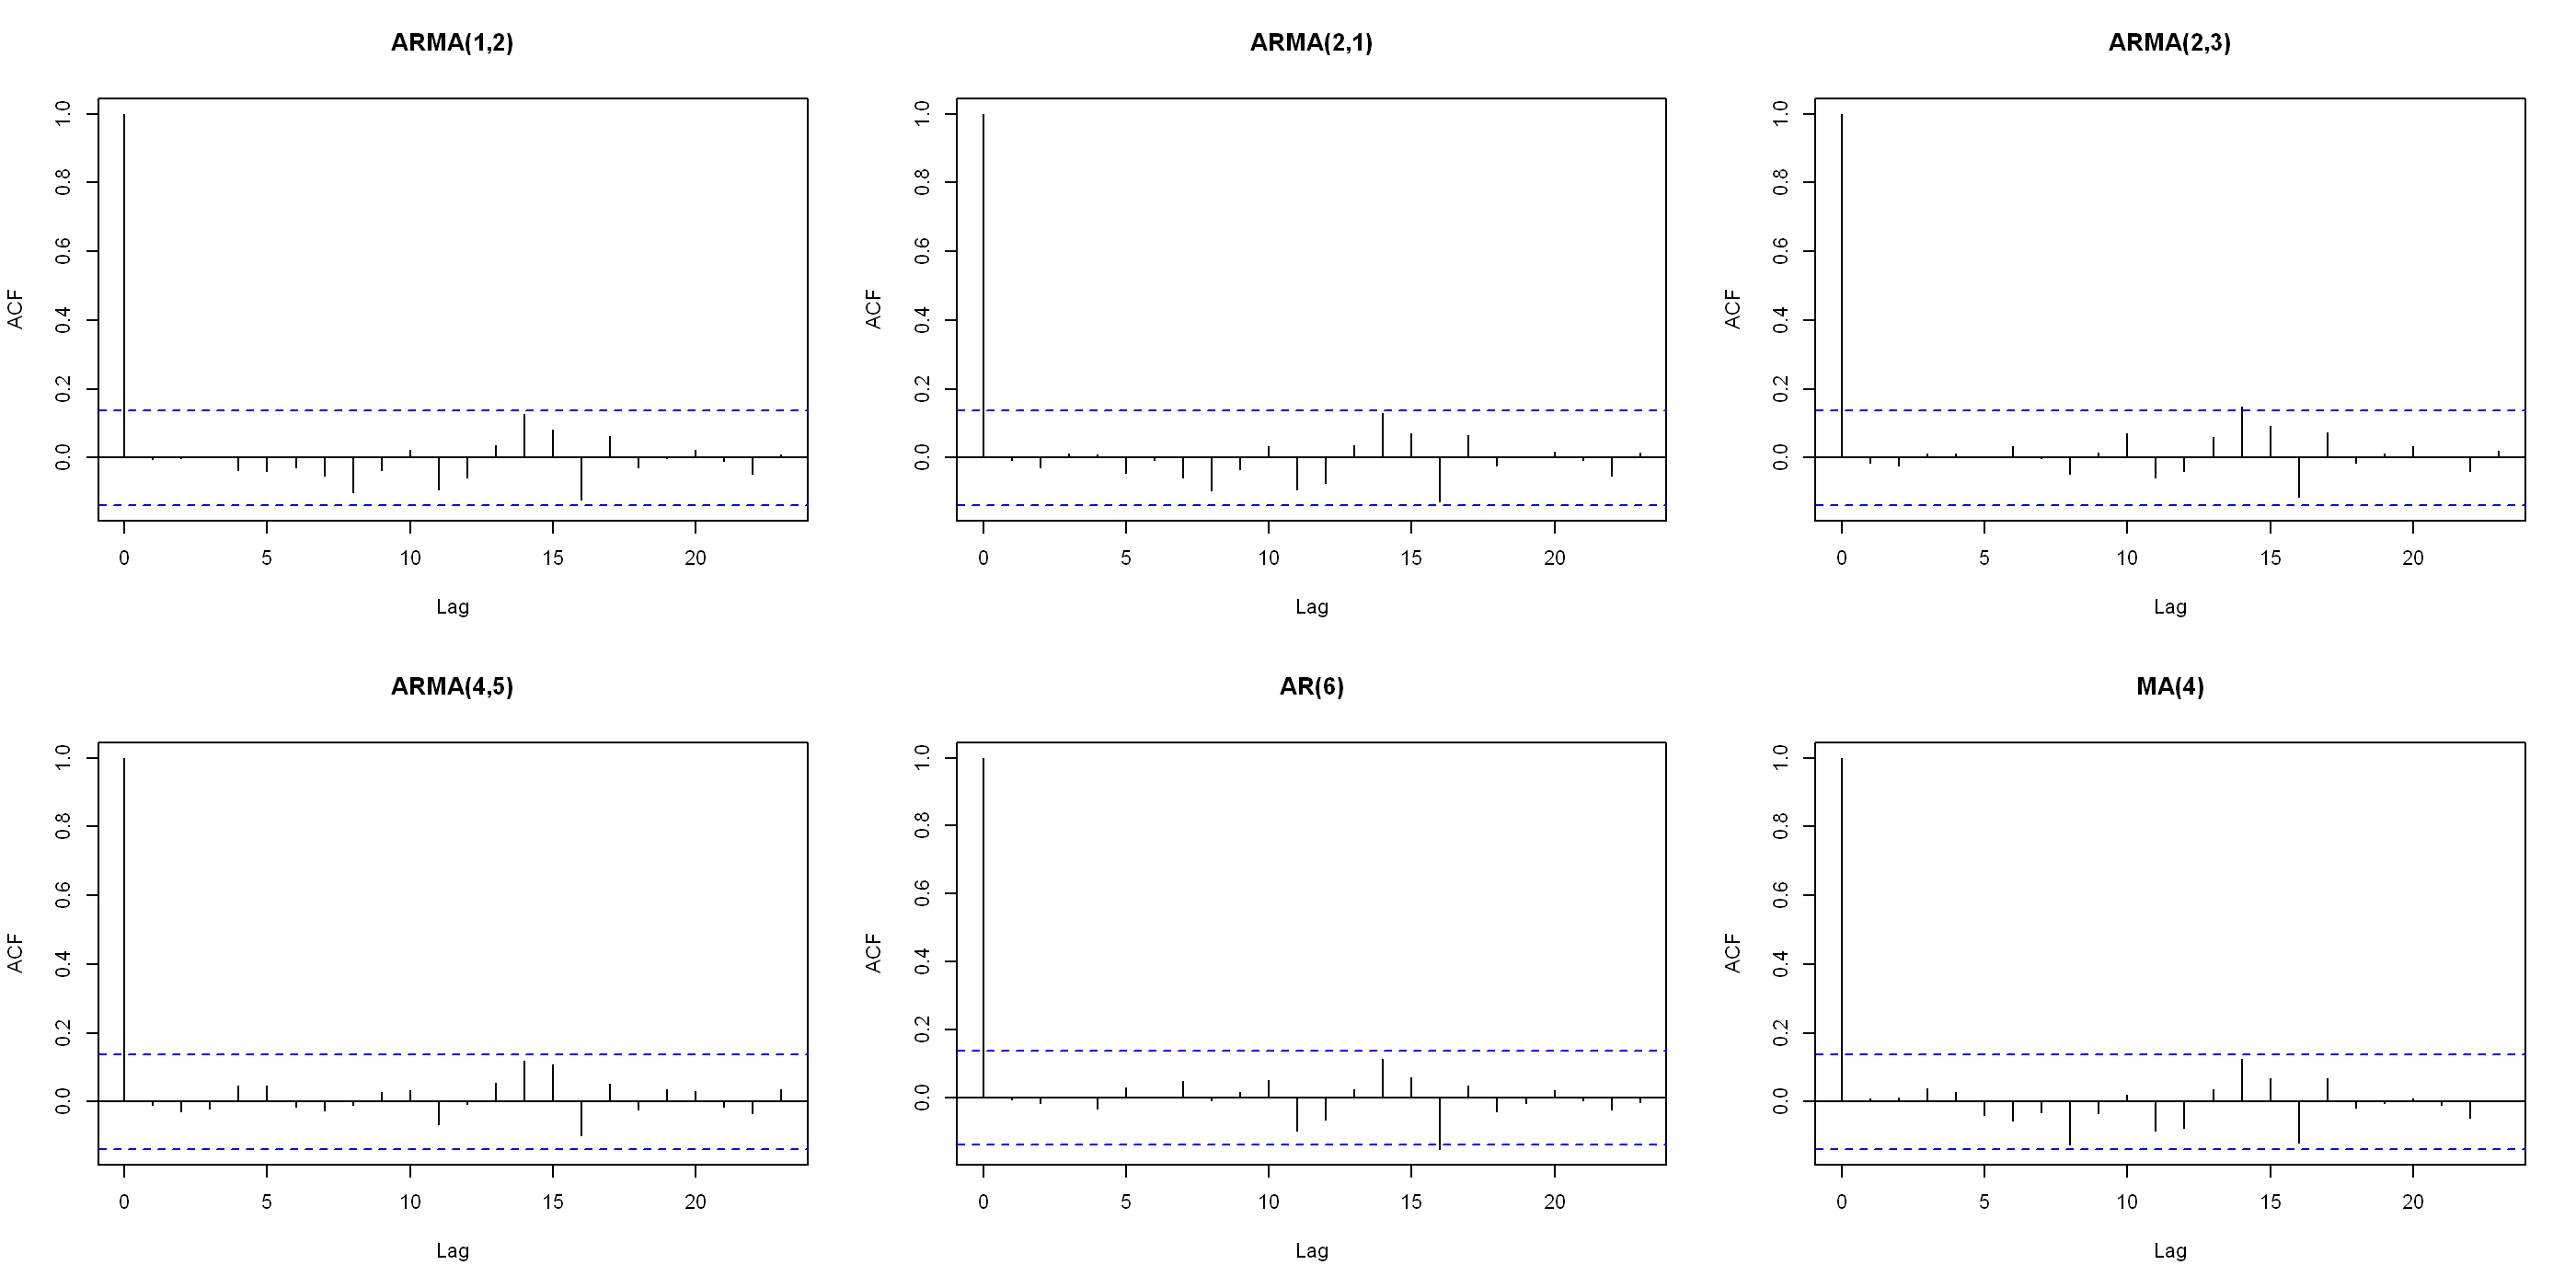

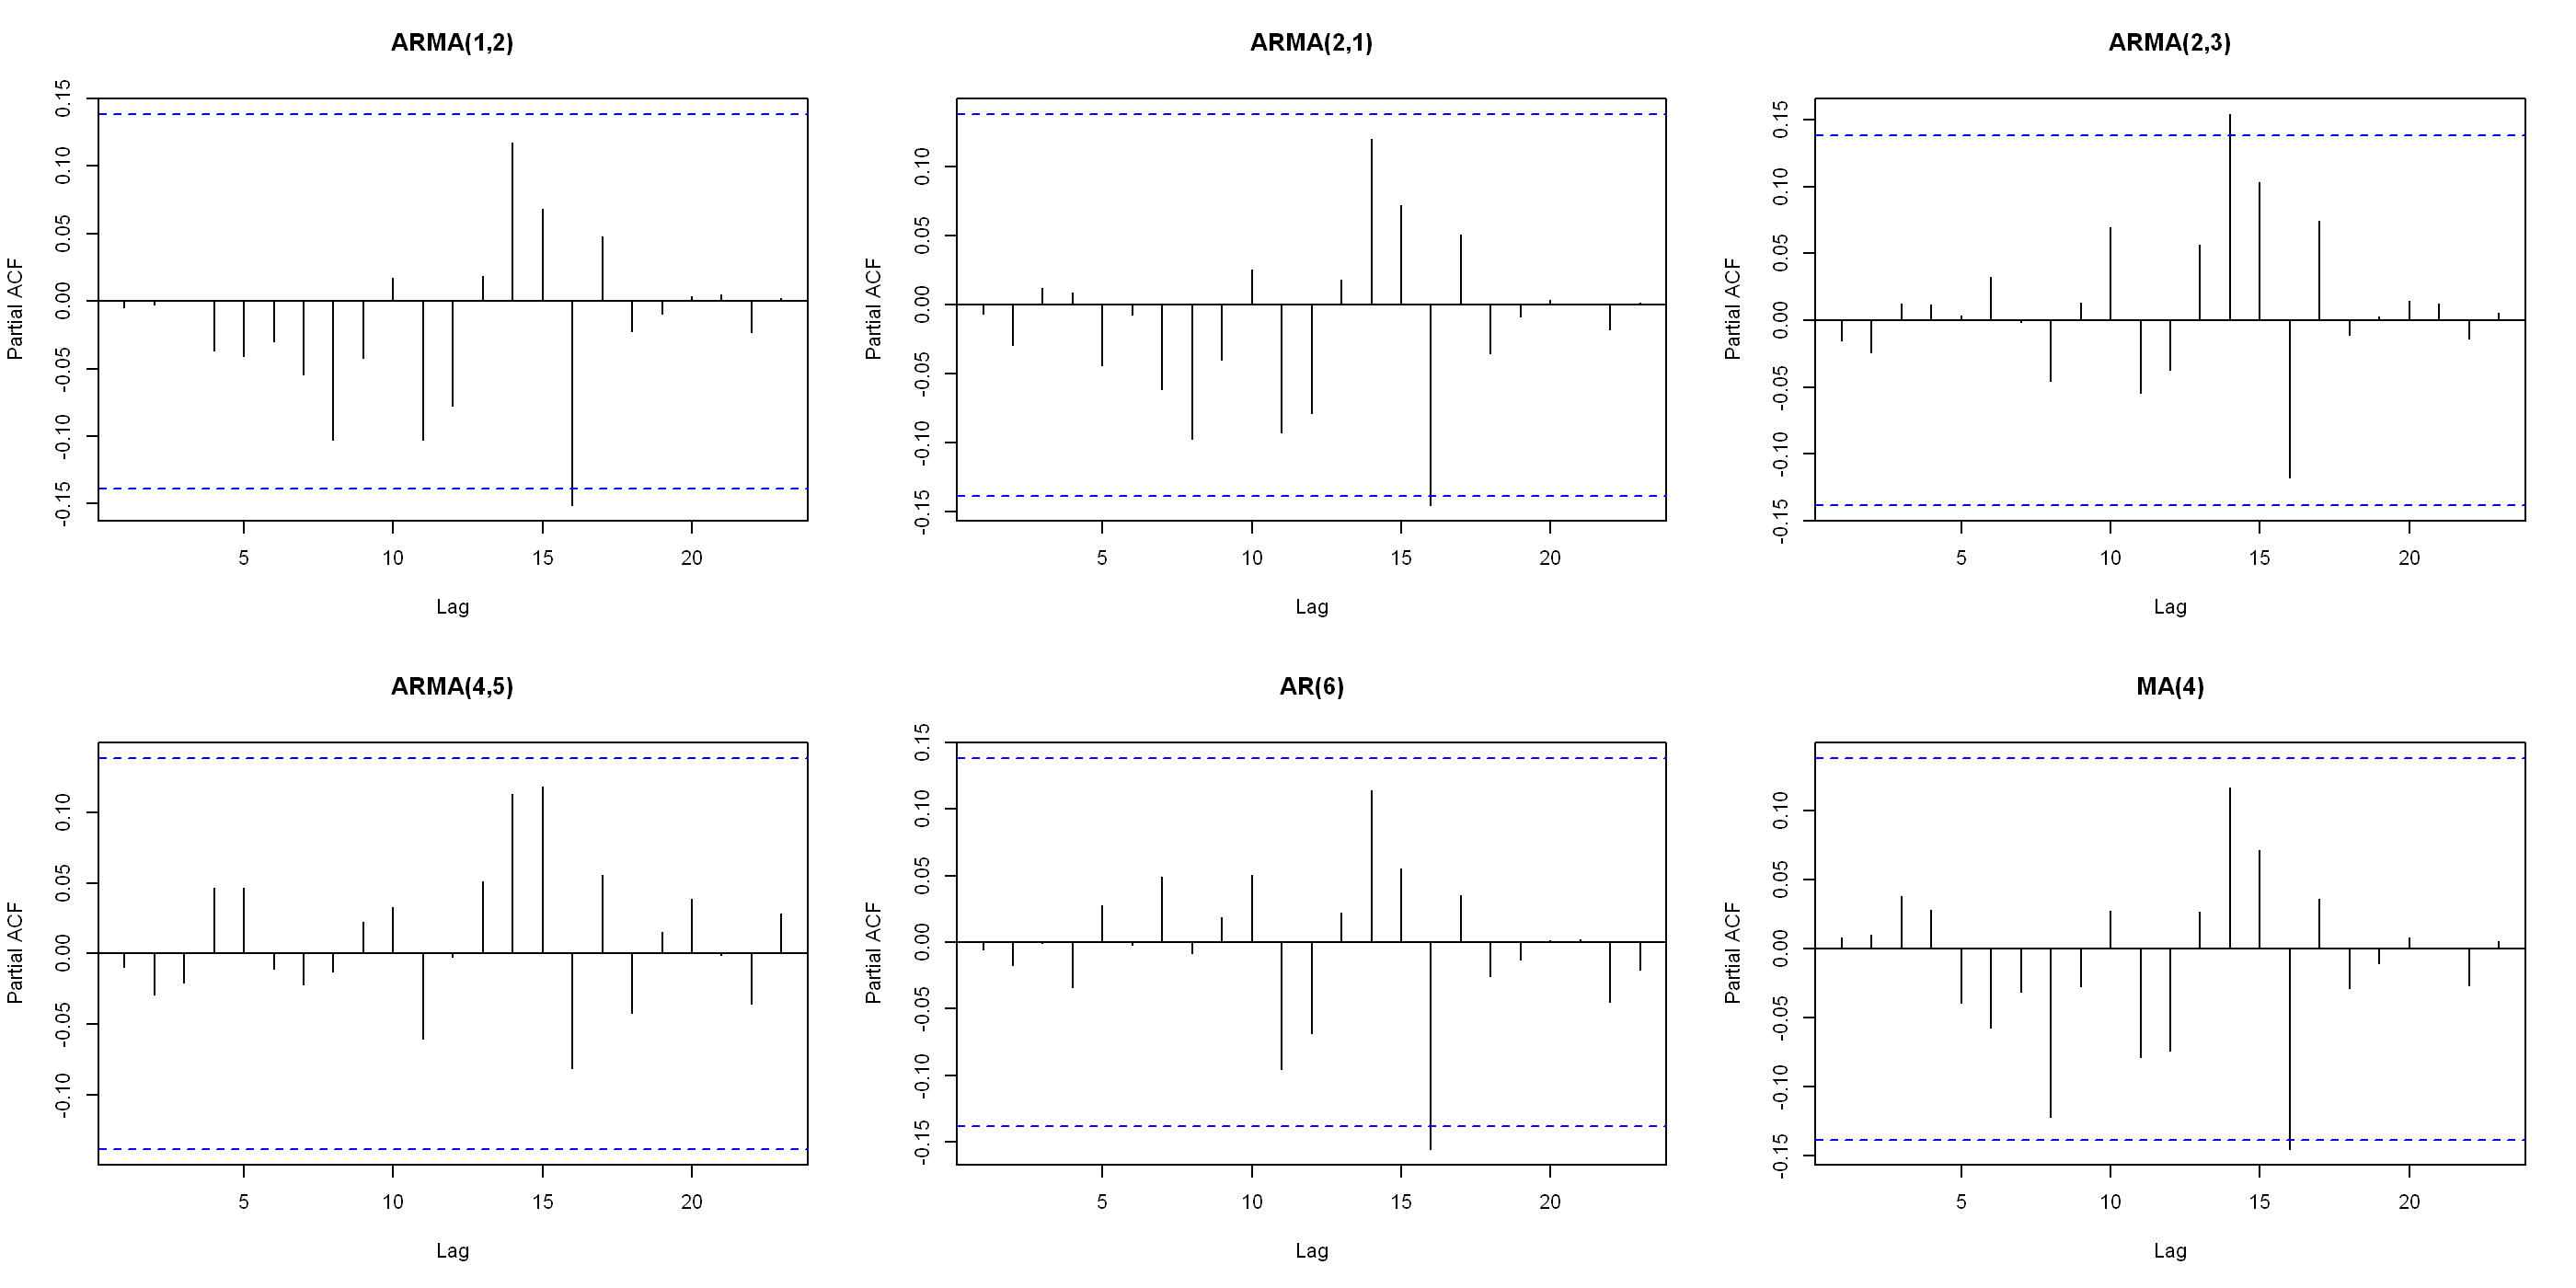

In [23]:
par(mfrow = c(2,3))
plot(ts,ARMA_pq[[2]]$residuals,main = labels_ARMA_pq[[2]])
plot(ts,ARMA_pq[[1+end]]$residuals,main = labels_ARMA_pq[[1+end]])
plot(ts,ARMA_pq[[3+end]]$residuals,main = labels_ARMA_pq[[3+end]])
plot(ts,ARMA_pq[[5+3*end]]$residuals,main = labels_ARMA_pq[[5+3*end]])
plot(ts,AR_p[[6]]$residuals,main = labels_AR_p[[6]])
plot(ts,MA_q[[4]]$residuals,main = labels_MA_q[[4]])

par(mfrow = c(2,3))
par(mfrow = c(2,3))
qqnorm(ARMA_pq[[2]]$residuals, main = labels_ARMA_pq[[2]])
qqline(ARMA_pq[[2]]$residuals, col="red")
qqnorm(ARMA_pq[[1+end]]$residuals, main = labels_ARMA_pq[[1+end]])
qqline(ARMA_pq[[1+end]]$residuals, col="red")
qqnorm(ARMA_pq[[3+end]]$residuals, main = labels_ARMA_pq[[3+end]])
qqline(ARMA_pq[[3+end]]$residuals, col="red")
qqnorm(ARMA_pq[[5+3*end]]$residuals, main = labels_ARMA_pq[[5+3*end]])
qqline(ARMA_pq[[5+3*end]]$residuals, col="red")
qqnorm(AR_p[[6]]$residuals, main = labels_AR_p[[6]])
qqline(AR_p[[6]]$residuals, col="red")
qqnorm(MA_q[[4]]$residuals, main = labels_MA_q[[4]])
qqline(MA_q[[4]]$residuals, col="red")

par(mfrow = c(2,3))
acf(ARMA_pq[[2]]$residuals,main = labels_ARMA_pq[[2]])
acf(ARMA_pq[[1+end]]$residuals,main = labels_ARMA_pq[[1+end]])
acf(ARMA_pq[[3+end]]$residuals,main = labels_ARMA_pq[[3+end]])
acf(ARMA_pq[[5+3*end]]$residuals,main = labels_ARMA_pq[[5+3*end]])
acf(AR_p[[6]]$residuals,main = labels_AR_p[[6]])
acf(MA_q[[4]]$residuals,main = labels_MA_q[[4]])

par(mfrow = c(2,3))
pacf(ARMA_pq[[2]]$residuals,main = labels_ARMA_pq[[2]])
pacf(ARMA_pq[[1+end]]$residuals,main = labels_ARMA_pq[[1+end]])
pacf(ARMA_pq[[3+end]]$residuals,main = labels_ARMA_pq[[3+end]])
pacf(ARMA_pq[[5+3*end]]$residuals,main = labels_ARMA_pq[[5+3*end]])
pacf(AR_p[[6]]$residuals,main = labels_AR_p[[6]])
pacf(MA_q[[4]]$residuals,main = labels_MA_q[[4]])


In [24]:


models <- list(
    list(m=ARMA_pq[[2]], lab=labels_ARMA_pq[[2]]),
    list(m=ARMA_pq[[1+end]], lab=labels_ARMA_pq[[1+end]]),
    list(m=ARMA_pq[[3+end]], lab=labels_ARMA_pq[[3+end]]),
    list(m=ARMA_pq[[5+3*end]], lab=labels_ARMA_pq[[5+3*end]]),
    list(m=AR_p[[6]], lab=labels_AR_p[[6]]),
    list(m=MA_q[[4]], lab=labels_MA_q[[4]])
)
for(x in models) {
    cat(x$lab, "\n")
    print(x)
    cat("\n")
}
# acf(ARMA_pq[[1+end]]$residuals,main = labels_ARMA_pq[[1+end]])
# acf(ARMA_pq[[3+end]]$residuals,main = labels_ARMA_pq[[3+end]])
# acf(ARMA_pq[[5+3*end]]$residuals,main = labels_ARMA_pq[[5+3*end]])
# acf(AR_p[[6]]$residuals,main = labels_AR_p[[6]])
# acf(MA_q[[4]]$residuals,main = labels_MA_q[[4]])

ARMA(1,2) 
$m

Call:
arima(x = ts, order = c(i, 0, j), method = "ML")

Coefficients:
         ar1     ma1     ma2  intercept
      0.5578  1.0414  0.2694     0.6489
s.e.  0.0839  0.0968  0.0944     0.3429

sigma^2 estimated as 0.8776:  log likelihood = -272.06,  aic = 554.12

$lab
[1] "ARMA(1,2)"


ARMA(2,1) 
$m

Call:
arima(x = ts, order = c(i, 0, j), method = "ML")

Coefficients:
         ar1      ar2     ma1  intercept
      0.8915  -0.2411  0.7061     0.6420
s.e.  0.0855   0.0856  0.0625     0.3207

sigma^2 estimated as 0.8772:  log likelihood = -272.01,  aic = 554.02

$lab
[1] "ARMA(2,1)"


ARMA(2,3) 
$m

Call:
arima(x = ts, order = c(i, 0, j), method = "ML")

Coefficients:
         ar1      ar2      ma1      ma2      ma3  intercept
      1.5797  -0.6268  -0.0210  -0.7655  -0.2135     0.5142
s.e.  0.0809   0.0818   0.1031   0.0453   0.1005     0.0480

sigma^2 estimated as 0.8353:  log likelihood = -268.43,  aic = 550.86

$lab
[1] "ARMA(2,3)"


ARMA(4,5) 
$m

Call:
arima(x = ts, or

In [25]:
str(ARMA_pq[[5+3*end]])


List of 14
 $ coef     : Named num [1:10] 1.292 -1.106 1.256 -0.548 0.27 ...
  ..- attr(*, "names")= chr [1:10] "ar1" "ar2" "ar3" "ar4" ...
 $ sigma2   : num 0.78
 $ var.coef : num [1:10, 1:10] 0.00927 -0.00899 0.00595 -0.00594 -0.00814 ...
  ..- attr(*, "dimnames")=List of 2
  .. ..$ : chr [1:10] "ar1" "ar2" "ar3" "ar4" ...
  .. ..$ : chr [1:10] "ar1" "ar2" "ar3" "ar4" ...
 $ mask     : logi [1:10] TRUE TRUE TRUE TRUE TRUE TRUE ...
 $ loglik   : num -264
 $ aic      : num 549
 $ arma     : int [1:7] 4 5 0 0 1 0 0
 $ residuals: Time-Series [1:200] from 1 to 200: 1.9891 2.2314 -0.0597 1.4317 0.388 ...
 $ call     : language arima(x = ts, order = c(i, 0, j), method = "ML")
 $ series   : chr "ts"
 $ code     : int 1
 $ n.cond   : num 0
 $ nobs     : int 200
 $ model    :List of 10
  ..$ phi  : num [1:4] 1.292 -1.106 1.256 -0.548
  ..$ theta: num [1:5] 0.27 0.233 -0.384 -0.838 -0.281
  ..$ Delta: num(0) 
  ..$ Z    : num [1:6] 1 0 0 0 0 0
  ..$ a    : num [1:6] -0.0488 -0.0365 -0.1445 0.43

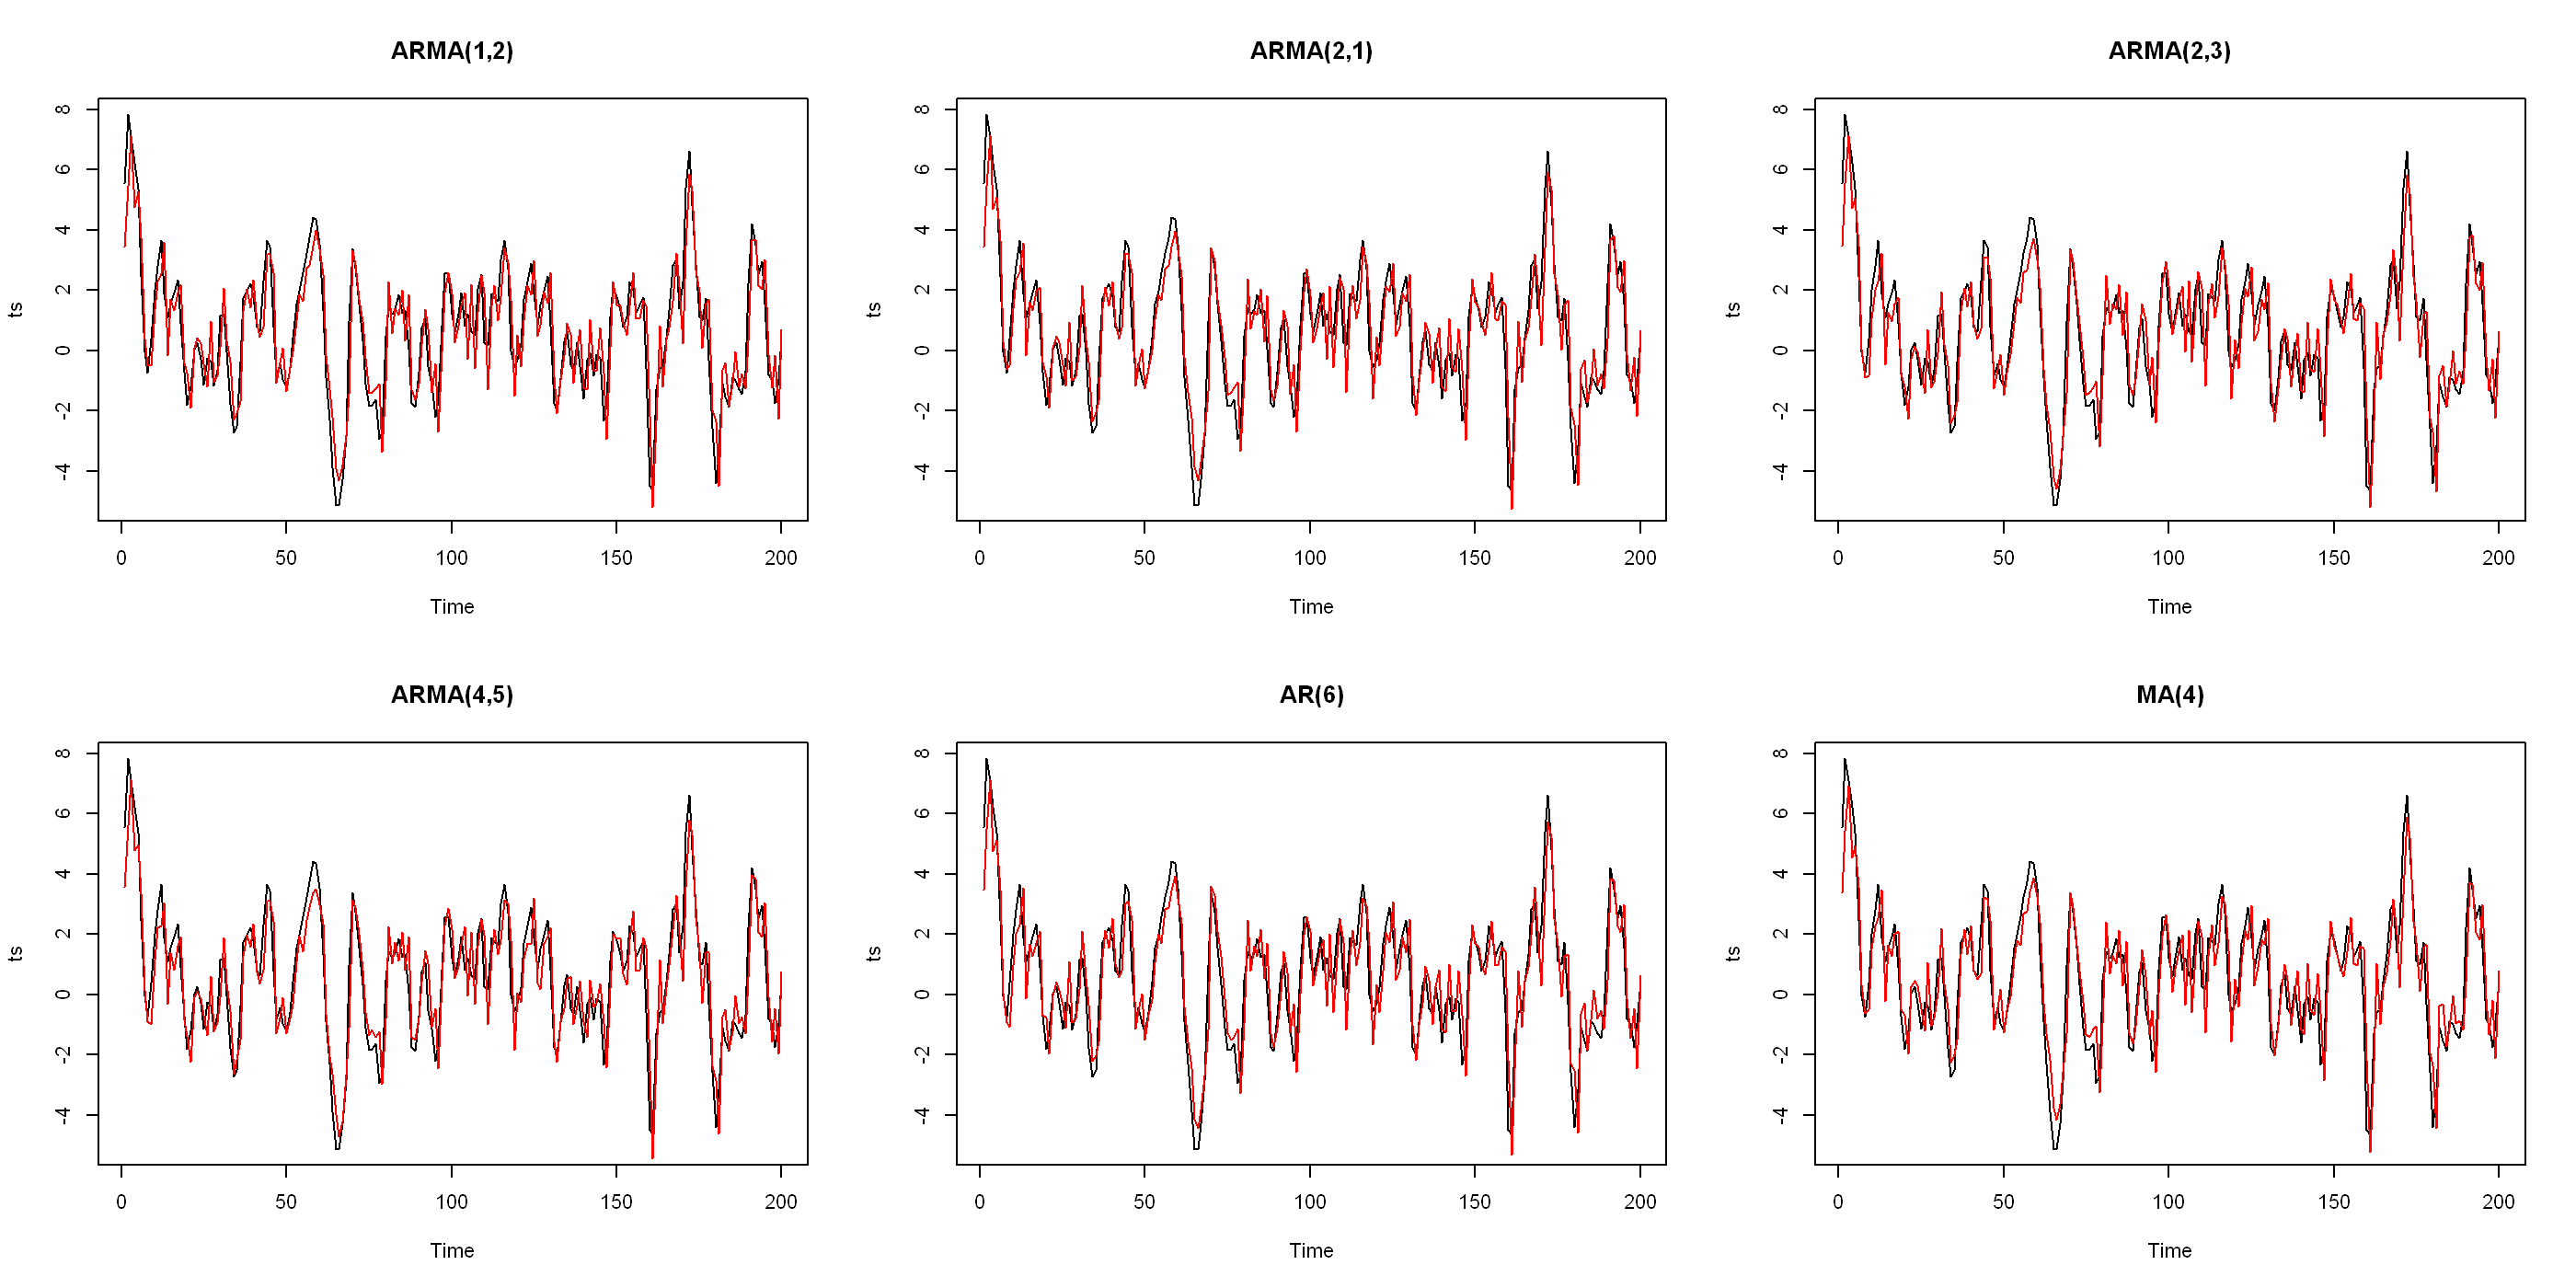

In [26]:
par(mfrow = c(2,3))
for(m in models) {
    fitted_vals <- as.numeric(ts) - as.numeric(m$m$residuals)
    plot(ts, main=m$lab)
    lines(fitted_vals, col="red")
}

All in all we argue that out of these models which we compare the ARMA(4,5) is the frontier, it has the lowest AIC, only one (out of the selected six) which remained "correctly" with the PACF bounds, and lastly why could argue (aside from the type I error) that ARMA(2,1), ARMA(1,2), AR(6), ARMA(2,3), MA(4) all do an ok job. Additionally the standard errors of the coefficients look fine (from a significance perspective).

In [34]:
library(forecast)
mm = auto.arima(ts,max.p = 6,max.q = 6,stepwise = FALSE, approximation = FALSE,trace=TRUE,ic="aic",max.order = 10)


 ARIMA(0,0,0) with zero mean     : 901.9945
 ARIMA(0,0,0) with non-zero mean : 888.4156
 ARIMA(0,0,1) with zero mean     : 681.7695
 ARIMA(0,0,1) with non-zero mean : 671.0929
 ARIMA(0,0,2) with zero mean     : 587.3701
 ARIMA(0,0,2) with non-zero mean : 581.034
 ARIMA(0,0,3) with zero mean     : 565.075
 ARIMA(0,0,3) with non-zero mean : 561.2883
 ARIMA(0,0,4) with zero mean     : 559.8666
 ARIMA(0,0,4) with non-zero mean : 557.3349
 ARIMA(0,0,5) with zero mean     : 559.8146
 ARIMA(0,0,5) with non-zero mean : 557.8588
 ARIMA(0,0,6) with zero mean     : 561.3539
 ARIMA(0,0,6) with non-zero mean : 559.6723
 ARIMA(1,0,0) with zero mean     : 662.9434
 ARIMA(1,0,0) with non-zero mean : 662.9963
 ARIMA(1,0,1) with zero mean     : 560.1018
 ARIMA(1,0,1) with non-zero mean : 559.434
 ARIMA(1,0,2) with zero mean     : 555.4556
 ARIMA(1,0,2) with non-zero mean : 554.1193
 ARIMA(1,0,3) with zero mean     : 557.449
 ARIMA(1,0,3) with non-zero mean : 556.0575
 ARIMA(1,0,4) with zero mean     : 

We compare with our "estimated best"

In [28]:
options(repr.plot.width = 14, repr.plot.height = 10, repr.plot.res = 200)


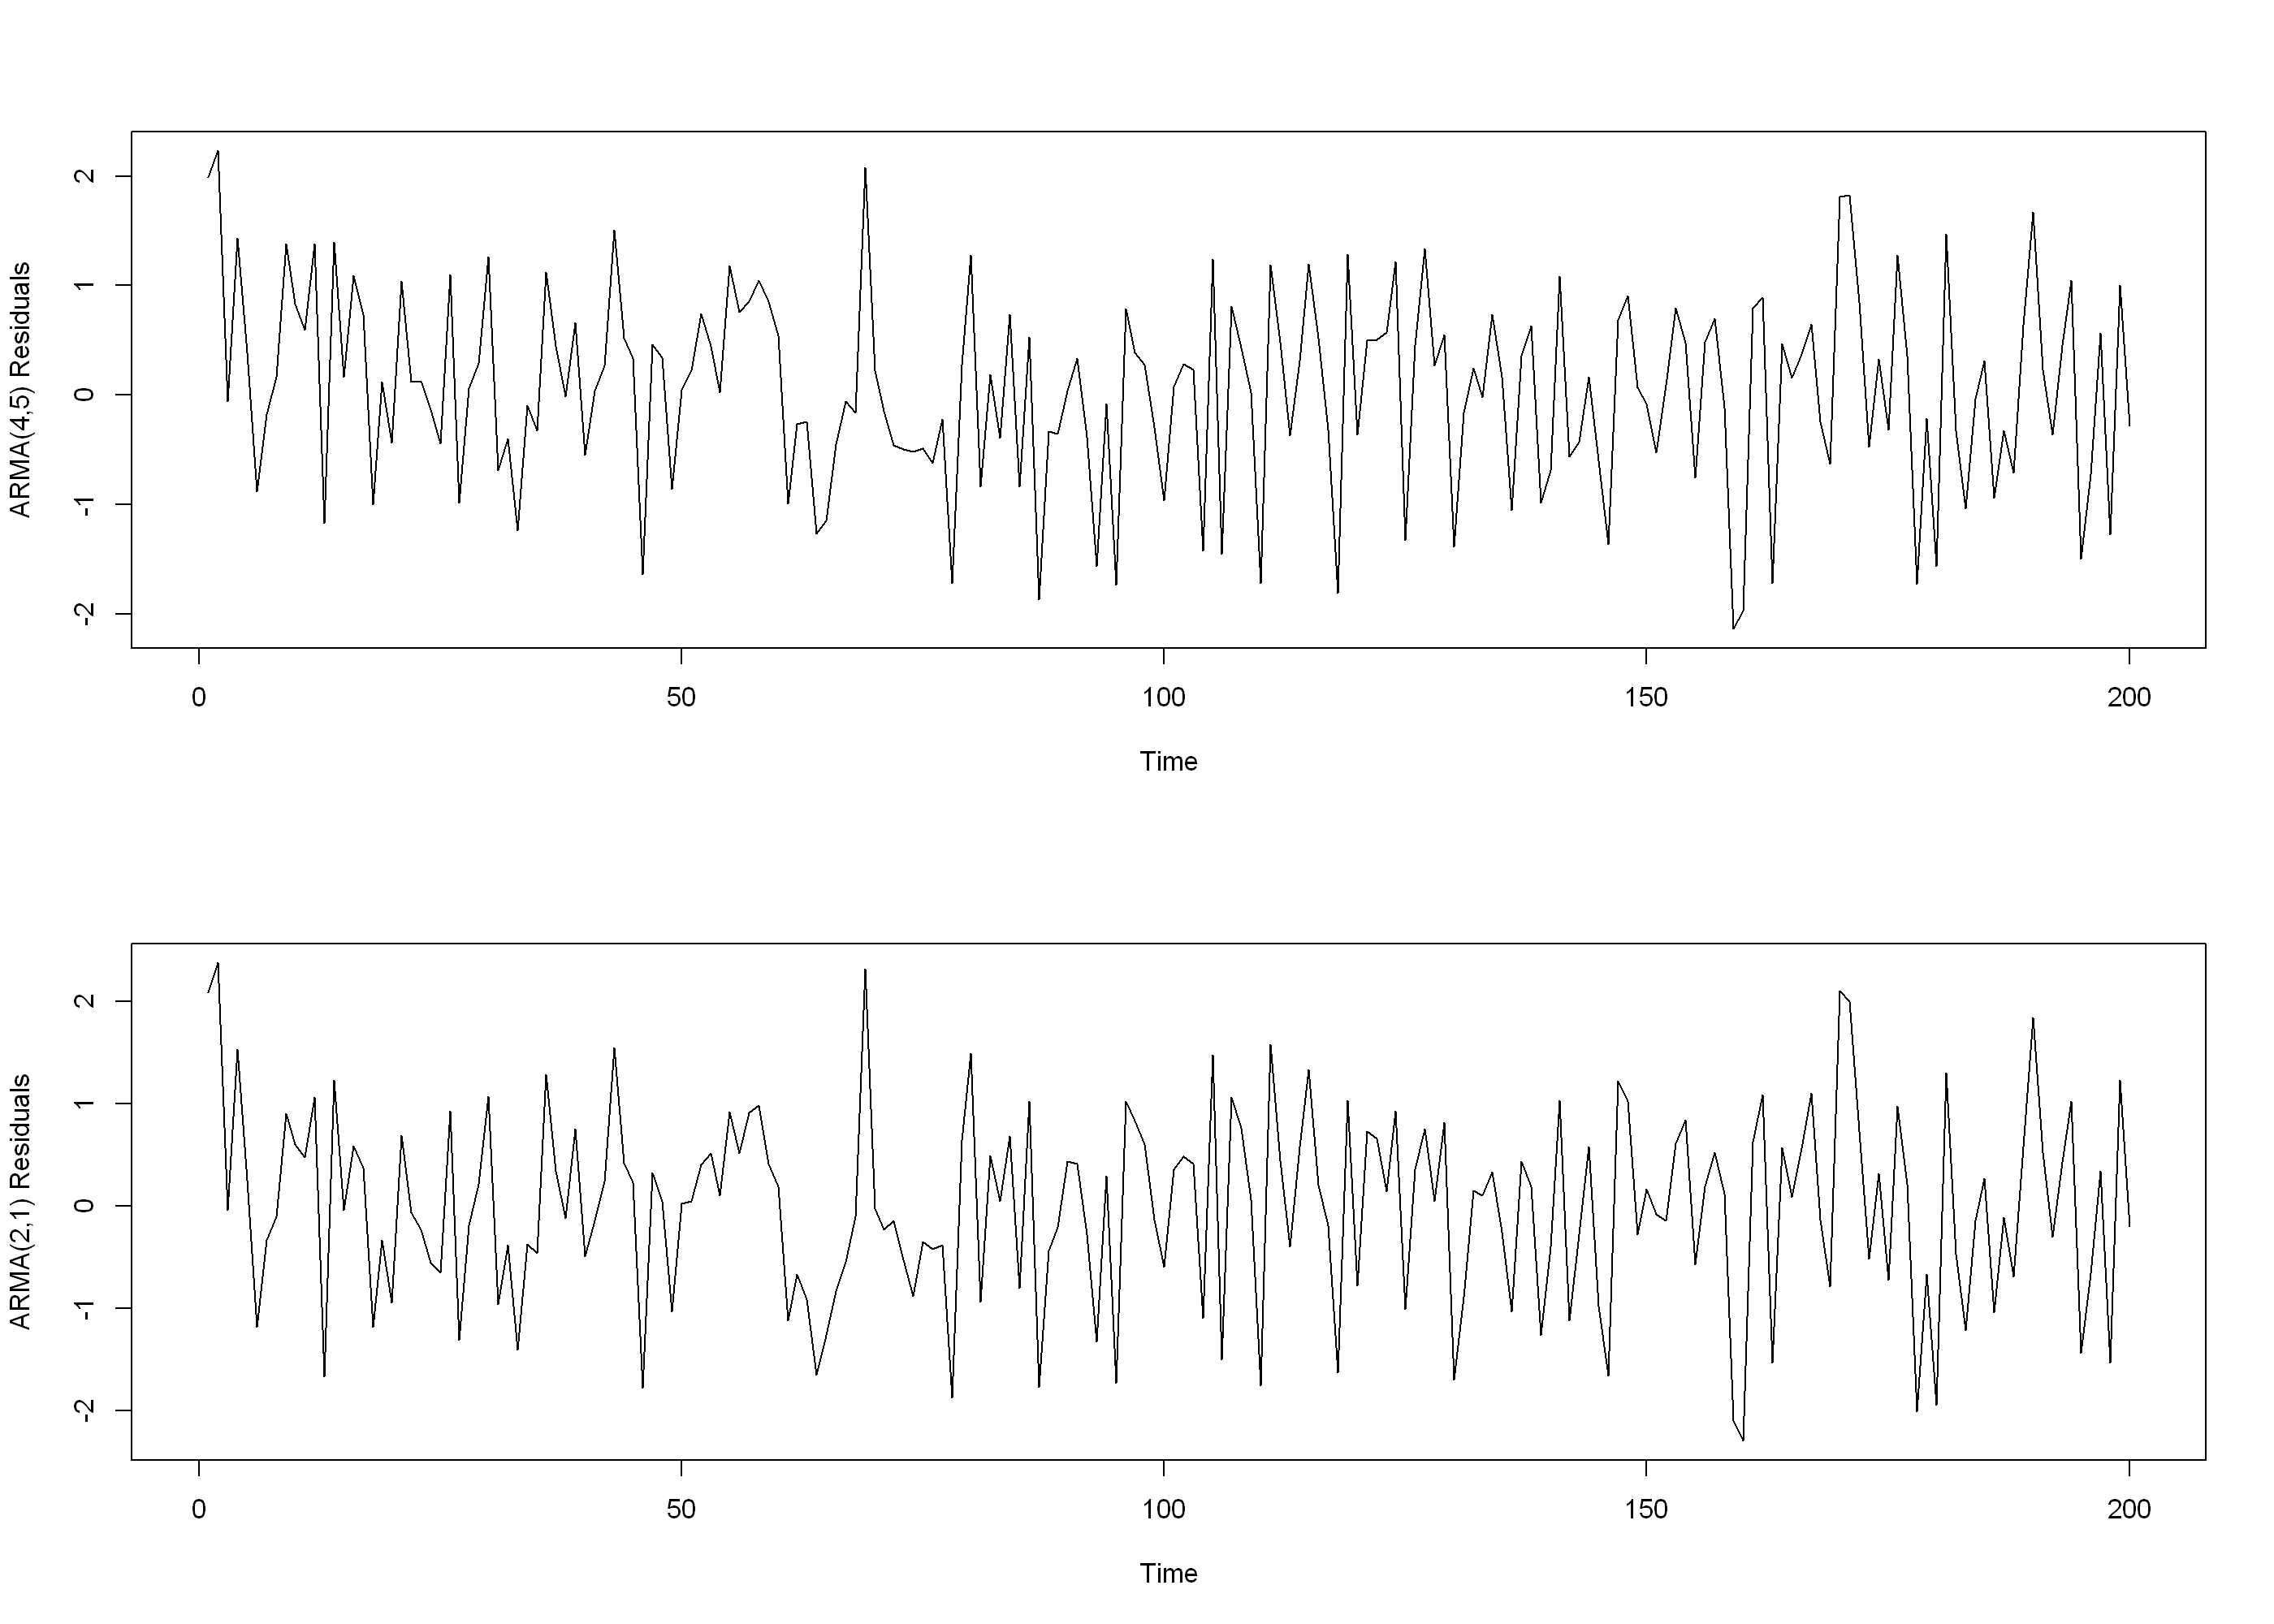

In [29]:
best = ARMA_pq[[5+3*end]]

par(mfrow = c(2,1))
plot(best$residuals,ylab = "ARMA(4,5) Residuals")
plot(mm$residuals, ylab = "ARMA(2,1) Residuals")